In [ ]:
import pandas as pd
import seaborn as sns
from pandas import read_csv
df = read_csv("/content/placement_predict_50k Dataset.csv")

In [ ]:
df.head(5)

,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,2,0,66.7,2.2,49.4,47.8,0,Low,0,0
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,1,0,48.2,2.4,26.7,25.8,0,Low,0,0
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,1,0,73.8,2.8,67.7,41.5,0,Low,1,0
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,2,0,69.8,2.7,66.9,48.0,0,Mid,1,0
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,4,1,73.1,2.1,71.7,61.7,1,High,1,0


In [ ]:
df['StudentID']
df.shape

(50000, 31)

In [ ]:
df['Gender']
df.shape

(50000, 31)

In [ ]:
df.dtypes

,0
StudentID,int64
Gender,object
City,object
CollegeTier,object
Stream,object
Specialisation,object
Hostel,object
HistoryOfBacklogs,object
SGPA_Sem1,float64
SGPA_Sem2,float64


In [ ]:
df.dtypes.value_counts()

,count
float64,15
int64,8
object,8


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 50000
Number of columns: 31


In [ ]:
print(df.columns.tolist())

['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           50000 non-null  int64  
 1   Gender              50000 non-null  object 
 2   City                50000 non-null  object 
 3   CollegeTier         50000 non-null  object 
 4   Stream              50000 non-null  object 
 5   Specialisation      50000 non-null  object 
 6   Hostel              50000 non-null  object 
 7   HistoryOfBacklogs   50000 non-null  object 
 8   SGPA_Sem1           50000 non-null  float64
 9   SGPA_Sem2           50000 non-null  float64
 10  SGPA_Sem3           50000 non-null  float64
 11  SGPA_Sem4           50000 non-null  float64
 12  SGPA_Sem5           50000 non-null  float64
 13  SGPA_Sem6           50000 non-null  float64
 14  SGPA_Sem7           50000 non-null  float64
 15  SGPA_Sem8           50000 non-null  float64
 16  CGPA

In [ ]:
df.isnull().sum()

,0
StudentID,0
Gender,0
City,0
CollegeTier,0
Stream,0
Specialisation,0
Hostel,0
HistoryOfBacklogs,0
SGPA_Sem1,0
SGPA_Sem2,0


In [ ]:
total_missing = df.isnull().sum().sum()

print("Total missing values:", total_missing)

Total missing values: 19976


In [ ]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Workshops             4488
AptitudeTestScore     4029
SoftSkillsRating      3526
CodingTestScore       2976
MockInterviewScore    4957
dtype: int64


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

print(missing_report[missing_report["Missing Values"] > 0])

                    Missing Values  Missing Percentage
Workshops                     4488               8.976
AptitudeTestScore             4029               8.058
SoftSkillsRating              3526               7.052
CodingTestScore               2976               5.952
MockInterviewScore            4957               9.914


In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
df.describe()

,StudentID,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,...,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,PlacementStatus,IsAnomaly
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,45512.000000,50000.000000,50000.000000,45971.000000,46474.000000,47024.000000,45043.00000,50000.000000,50000.000000,50000.000000
mean,25000.500000,7.210583,7.222243,7.235398,7.247290,7.258639,7.274511,7.282720,7.293704,7.246154,...,1.804469,1.931420,0.735460,68.859261,3.154211,57.411273,55.40853,0.533000,0.657120,0.035000
std,14433.901067,1.517846,1.532008,1.551632,1.570629,1.587829,1.603261,1.621605,1.638112,1.615686,...,1.036193,1.175391,0.717167,15.365230,0.981333,20.979679,17.52218,0.498915,0.474677,0.183782
min,1.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,0.000000,0.000000,0.000000,30.000000,1.000000,0.000000,15.90000,0.000000,0.000000,0.000000
25%,12500.750000,6.090000,6.090000,6.080000,6.070000,6.070000,6.080000,6.060000,6.060000,6.040000,...,1.000000,1.000000,0.000000,58.500000,2.400000,45.900000,44.20000,0.000000,0.000000,0.000000
50%,25000.500000,7.190000,7.210000,7.220000,7.240000,7.260000,7.280000,7.300000,7.310000,7.250000,...,2.000000,2.000000,1.000000,69.900000,3.200000,57.700000,54.70000,1.000000,1.000000,0.000000
75%,37500.250000,8.340000,8.360000,8.400000,8.430000,8.460000,8.500000,8.520000,8.560000,8.480000,...,3.000000,3.000000,1.000000,79.700000,3.900000,73.300000,69.20000,1.000000,1.000000,0.000000
max,50000.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,...,4.000000,5.000000,3.000000,100.000000,5.000000,100.000000,100.00000,1.000000,1.000000,1.000000


In [ ]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numerical columns:")
print(numerical_columns.tolist())

print("\nCategorical columns:")
print(categorical_columns.tolist())

Numerical columns:
['StudentID', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'PlacementStatus', 'IsAnomaly']

Categorical columns:
['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'CGPA_Tier']


In [ ]:
for column in categorical_columns:
    print("\nColumn:", column)
    print(df[column].unique())


Column: Gender
['Male' 'Female']

Column: City
['Ahmedabad' 'Mumbai' 'Kolkata' 'Jaipur' 'Pune' 'Hyderabad' 'Delhi'
 'Chennai' 'Bangalore' 'Kochi']

Column: CollegeTier
['Tier2' 'Tier1' 'Tier3']

Column: Stream
['ECE' 'IT' 'CS' 'EE' 'Mechanical' 'Civil']

Column: Specialisation
['Networking' 'DataScience' 'AI' 'Embedded']

Column: Hostel
['No' 'Yes']

Column: HistoryOfBacklogs
['No' 'Yes']

Column: CGPA_Tier
['Low' 'Mid' 'High']


In [ ]:
df.nunique()

,0
StudentID,50000
Gender,2
City,10
CollegeTier,3
Stream,6
Specialisation,4
Hostel,2
HistoryOfBacklogs,2
SGPA_Sem1,601
SGPA_Sem2,601


In [ ]:
df["Gender"].value_counts()

,count
Gender,
Male,30133
Female,19867


In [ ]:
df["Gender"].value_counts(dropna=False)

,count
Gender,
Male,30133
Female,19867


In [ ]:
df["PlacementStatus"].value_counts()

,count
PlacementStatus,
1,32856
0,17144


In [ ]:
placement_percentage = df["PlacementStatus"].value_counts(normalize=True) * 100

print(placement_percentage)

PlacementStatus
1    65.712
0    34.288
Name: proportion, dtype: float64


In [ ]:
print("Minimum CGPA:", df["CGPA"].min())
print("Maximum CGPA:", df["CGPA"].max())
print("Average CGPA:", df["CGPA"].mean())

Minimum CGPA: 4.0
Maximum CGPA: 10.0
Average CGPA: 7.246153799999999


In [ ]:
gender_placement = pd.crosstab(
    df["Gender"],
    df["PlacementStatus"]
)

print(gender_placement)

PlacementStatus      0      1
Gender                       
Female            6848  13019
Male             10296  19837


In [ ]:
average_cgpa = df.groupby("PlacementStatus")["CGPA"].mean()

print(average_cgpa)

PlacementStatus
0    5.794713
1    8.003504
Name: CGPA, dtype: float64


In [ ]:
placement_analysis = df.groupby("PlacementStatus")[
    [
        "CGPA",
        "AttendancePercent",
        "AptitudeTestScore",
        "CodingTestScore",
        "MockInterviewScore",
        "SoftSkillsRating"
    ]
].mean()

print(placement_analysis)

                     CGPA  AttendancePercent  AptitudeTestScore  \
PlacementStatus                                                   
0                5.794713          67.142450          56.541775   
1                8.003504          81.702063          75.256977   

                 CodingTestScore  MockInterviewScore  SoftSkillsRating  
PlacementStatus                                                         
0                      39.602898           39.190296          2.304618  
1                      66.693381           63.855789          3.596675  


In [ ]:
highest_cgpa_students = df.sort_values(
    by="CGPA",
    ascending=False
)

highest_cgpa_students.head(10)

,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly
15902,15903,Female,Mumbai,Tier2,CS,Embedded,No,No,9.76,10.0,...,3,2,90.6,3.1,85.7,65.8,0,High,1,0
24394,24395,Male,Pune,Tier1,ECE,AI,Yes,No,10.00,10.0,...,2,1,100.0,4.6,66.2,75.0,0,High,1,0
46209,46210,Female,Jaipur,Tier1,IT,DataScience,No,No,10.00,10.0,...,3,2,86.7,4.5,85.0,70.8,1,High,1,0
46119,46120,Male,Ahmedabad,Tier1,CS,AI,Yes,No,10.00,10.0,...,3,1,72.9,5.0,86.8,70.9,1,High,1,0
36287,36288,Male,Chennai,Tier2,Mechanical,AI,Yes,No,9.70,10.0,...,3,1,88.3,3.1,86.1,NaN,1,High,1,0
49925,49926,Male,Hyderabad,Tier2,IT,Embedded,Yes,No,9.32,10.0,...,3,2,74.1,NaN,NaN,66.7,1,High,1,0
19086,19087,Female,Jaipur,Tier1,IT,Networking,Yes,No,10.00,10.0,...,4,1,79.6,2.6,76.3,67.9,1,High,1,0
18963,18964,Male,Mumbai,Tier2,CS,DataScience,Yes,No,9.88,9.9,...,2,1,88.5,3.8,73.9,81.0,1,High,1,0
36332,36333,Female,Kolkata,Tier2,CS,DataScience,Yes,No,10.00,10.0,...,2,1,89.1,4.7,60.2,58.1,0,High,1,0
8362,8363,Male,Pune,Tier1,Civil,DataScience,Yes,No,10.00,10.0,...,3,1,92.7,3.1,68.7,66.1,1,High,1,0


In [ ]:
rows_with_missing_values = df[df.isnull().any(axis=1)]

rows_with_missing_values.head()

,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,2,0,66.7,2.2,49.4,47.8,0,Low,0,0
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,4,1,73.1,2.1,71.7,61.7,1,High,1,0
5,6,Male,Ahmedabad,Tier2,EE,Networking,No,No,10.00,10.00,...,4,1,81.5,3.9,NaN,75.3,0,High,1,0
7,8,Male,Delhi,Tier2,Mechanical,Embedded,Yes,No,5.87,5.64,...,0,0,NaN,2.0,35.2,27.8,0,Low,0,0
9,10,Female,Hyderabad,Tier2,CS,DataScience,No,No,8.26,8.29,...,1,0,59.0,2.7,74.3,42.4,1,High,1,0


In [ ]:
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())
print("Total missing values:", df.isnull().sum().sum())

print("\nNumerical columns:")
print(df.select_dtypes(include=["int64", "float64"]).columns.tolist())

print("\nCategorical columns:")
print(df.select_dtypes(include=["object"]).columns.tolist())

DATASET SUMMARY
Dataset shape: (50000, 31)
Number of rows: 50000
Number of columns: 31
Duplicate rows: 0
Total missing values: 19976

Numerical columns:
['StudentID', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'PlacementStatus', 'IsAnomaly']

Categorical columns:
['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'CGPA_Tier']


In [ ]:
# ==========================================================
# 1. IMPORT REQUIRED LIBRARIES
# ==========================================================

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# ==========================================================
# 2. LOAD THE DATASET
# ==========================================================

file_path = "/content/placement_predict_50k Dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

display(df.head())


# ==========================================================
# 3. CHECK TARGET COLUMN
# ==========================================================

print("\nPlacementStatus values:")
print(df["PlacementStatus"].value_counts())

print("\nPlacementStatus percentages:")
print(df["PlacementStatus"].value_counts(normalize=True) * 100)


# ==========================================================
# 4. REMOVE UNNECESSARY COLUMNS
# ==========================================================

# StudentID is only an identification number.
# IsAnomaly is not needed for placement prediction.

columns_to_remove = [
    "StudentID",
    "IsAnomaly"
]

df = df.drop(
    columns=columns_to_remove,
    errors="ignore"
)

print("\nColumns removed:", columns_to_remove)
print("Remaining columns:", df.shape[1])


# ==========================================================
# 5. REMOVE ROWS WHERE TARGET IS MISSING
# ==========================================================

df = df.dropna(subset=["PlacementStatus"])

print("\nDataset shape after checking target:", df.shape)


# ==========================================================
# 6. SEPARATE INPUT AND OUTPUT
# ==========================================================

# X contains the student information.
# y contains the result we want to predict.

X = df.drop("PlacementStatus", axis=1)

y = df["PlacementStatus"]

print("\nInput shape:", X.shape)
print("Target shape:", y.shape)


# ==========================================================
# 7. IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
# ==========================================================

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\nNumerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)


# ==========================================================
# 8. CREATE NUMERICAL DATA PROCESSING
# ==========================================================

# Missing numerical values are replaced with the median.
# StandardScaler places numerical values on a similar scale.

numerical_transformer = Pipeline(
    steps=[
        (
            "missing_value_handler",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ==========================================================
# 9. CREATE CATEGORICAL DATA PROCESSING
# ==========================================================

# Missing text values are replaced with the most common value.
# OneHotEncoder converts text values into numerical columns.

categorical_transformer = Pipeline(
    steps=[
        (
            "missing_value_handler",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# ==========================================================
# 10. COMBINE THE PREPROCESSING STEPS
# ==========================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical_processing",
            numerical_transformer,
            numerical_columns
        ),
        (
            "categorical_processing",
            categorical_transformer,
            categorical_columns
        )
    ]
)


# ==========================================================
# 11. CREATE THE RANDOM FOREST MODEL
# ==========================================================

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


# ==========================================================
# 12. CREATE COMPLETE MACHINE-LEARNING PIPELINE
# ==========================================================

placement_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            model
        )
    ]
)


# ==========================================================
# 13. SPLIT THE DATASET
# ==========================================================

# 80% data is used for training.
# 20% data is used for testing.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])


# ==========================================================
# 14. TRAIN THE MODEL
# ==========================================================

print("\nTraining started...")

placement_model.fit(X_train, y_train)

print("Training completed successfully")


# ==========================================================
# 15. MAKE PREDICTIONS
# ==========================================================

y_prediction = placement_model.predict(X_test)


# ==========================================================
# 16. CHECK MODEL ACCURACY
# ==========================================================

accuracy = accuracy_score(
    y_test,
    y_prediction
)

print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

print(f"Accuracy: {accuracy * 100:.2f}%")


# ==========================================================
# 17. CLASSIFICATION REPORT
# ==========================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_prediction,
        zero_division=0
    )
)


# ==========================================================
# 18. CONFUSION MATRIX
# ==========================================================

confusion = confusion_matrix(
    y_test,
    y_prediction
)

confusion_df = pd.DataFrame(
    confusion,
    index=[
        "Actual Not Placed",
        "Actual Placed"
    ],
    columns=[
        "Predicted Not Placed",
        "Predicted Placed"
    ]
)

print("\nConfusion Matrix:")

display(confusion_df)


# ==========================================================
# 19. CHECK TRAINING AND TESTING ACCURACY
# ==========================================================

training_prediction = placement_model.predict(X_train)

training_accuracy = accuracy_score(
    y_train,
    training_prediction
)

testing_accuracy = accuracy_score(
    y_test,
    y_prediction
)

print(f"\nTraining accuracy: {training_accuracy * 100:.2f}%")
print(f"Testing accuracy: {testing_accuracy * 100:.2f}%")


# ==========================================================
# 20. SAVE THE TRAINED MODEL
# ==========================================================

model_file = "/content/placement_prediction_model.pkl"

joblib.dump(
    placement_model,
    model_file
)

print("\nModel saved successfully")
print("Saved location:", model_file)

Dataset loaded successfully
Dataset shape: (50000, 31)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,2,0,66.7,2.2,49.4,47.8,0,Low,0,0
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,1,0,48.2,2.4,26.7,25.8,0,Low,0,0
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,1,0,73.8,2.8,67.7,41.5,0,Low,1,0
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,2,0,69.8,2.7,66.9,48.0,0,Mid,1,0
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,4,1,73.1,2.1,71.7,61.7,1,High,1,0



PlacementStatus values:
PlacementStatus
1    32856
0    17144
Name: count, dtype: int64

PlacementStatus percentages:
PlacementStatus
1    65.712
0    34.288
Name: proportion, dtype: float64

Columns removed: ['StudentID', 'IsAnomaly']
Remaining columns: 29

Dataset shape after checking target: (50000, 29)

Input shape: (50000, 28)
Target shape: (50000,)

Numerical columns:
['SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular']

Categorical columns:
['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'CGPA_Tier']

Training rows: 40000
Testing rows: 10000

Training started...
Training completed successfully

MODEL EVALUATION
Accuracy: 91.75%

Classification Report:
              precision    reca

,Predicted Not Placed,Predicted Placed
Actual Not Placed,3030,399
Actual Placed,426,6145



Training accuracy: 97.18%
Testing accuracy: 91.75%

Model saved successfully
Saved location: /content/placement_prediction_model.pkl


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=confusion_df)

https://docs.google.com/spreadsheets/d/1X01X2PRVj15EtWqmguT0CLnZLmoe--pqyqHVyJJk0tI/edit#gid=0


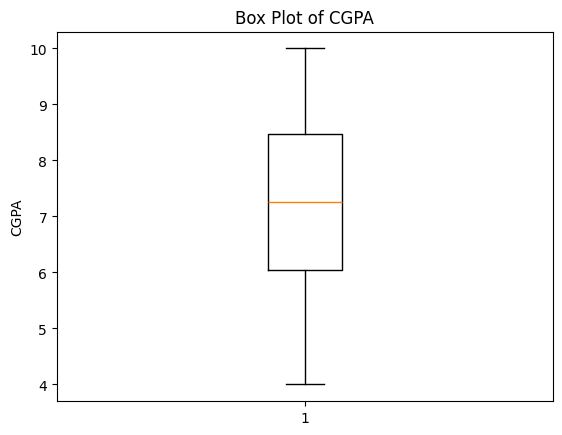

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df["CGPA"].dropna())
plt.title("Box Plot of CGPA")
plt.ylabel("CGPA")
plt.show()

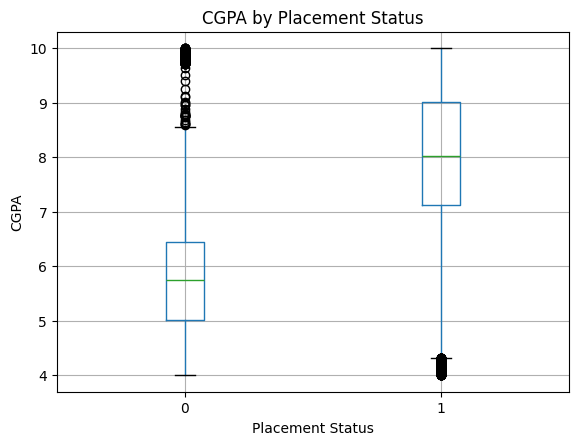

In [ ]:
df.boxplot(
    column="CGPA",
    by="PlacementStatus"
)

plt.title("CGPA by Placement Status")
plt.suptitle("")
plt.xlabel("Placement Status")
plt.ylabel("CGPA")
plt.show()

In [ ]:
import seaborn as sns

In [ ]:
# Numerical vs Categorical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'PlacementStatus']
Categorical Features: ['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'CGPA_Tier']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv("/content/placement_predict_50k Dataset.csv")

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully
Rows: 50000
Columns: 31


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,2,0,66.7,2.2,49.4,47.8,0,Low,0,0
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,1,0,48.2,2.4,26.7,25.8,0,Low,0,0
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,1,0,73.8,2.8,67.7,41.5,0,Low,1,0
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,2,0,69.8,2.7,66.9,48.0,0,Mid,1,0
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,4,1,73.1,2.1,71.7,61.7,1,High,1,0


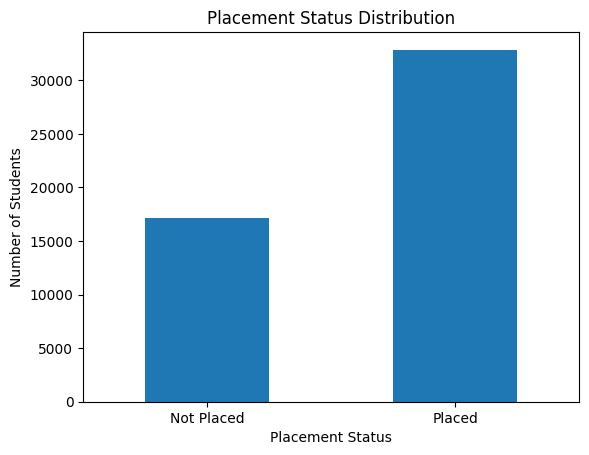

In [ ]:
placement_counts = df["PlacementStatus"].value_counts().sort_index()

placement_counts.index = ["Not Placed", "Placed"]

placement_counts.plot(kind="bar")

plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

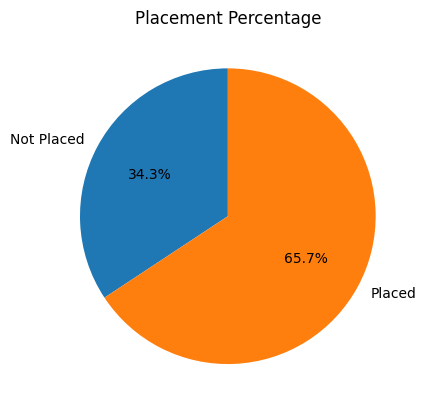

In [ ]:
placement_counts = df["PlacementStatus"].value_counts().sort_index()

plt.pie(
    placement_counts,
    labels=["Not Placed", "Placed"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Placement Percentage")
plt.show()

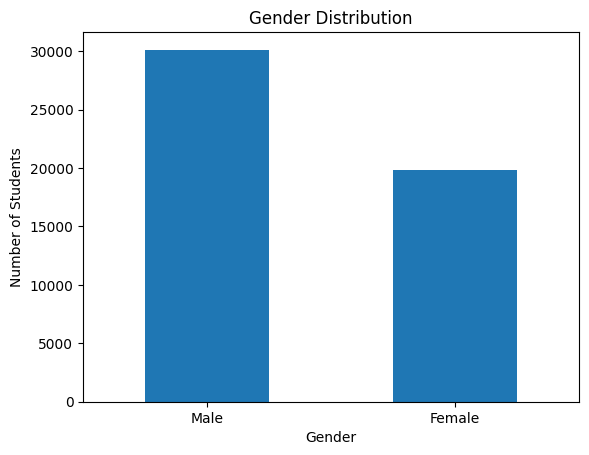

In [ ]:
gender_counts = df["Gender"].value_counts()

gender_counts.plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

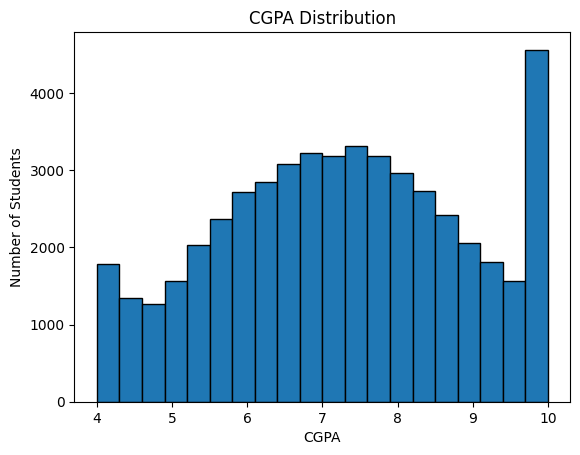

In [ ]:
plt.hist(
    df["CGPA"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title("CGPA Distribution")
plt.xlabel("CGPA")
plt.ylabel("Number of Students")
plt.show()

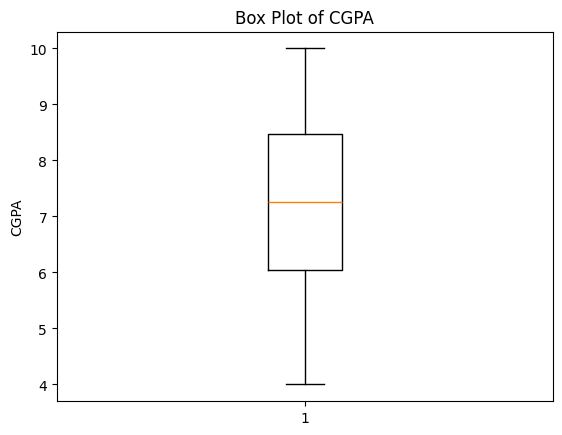

In [ ]:
plt.boxplot(df["CGPA"].dropna())

plt.title("Box Plot of CGPA")
plt.ylabel("CGPA")
plt.show()

/tmp/ipykernel_663/3662877499.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


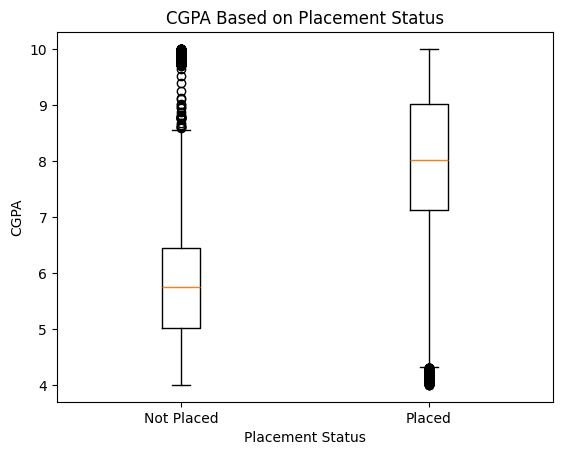

In [ ]:
not_placed_cgpa = df[df["PlacementStatus"] == 0]["CGPA"].dropna()
placed_cgpa = df[df["PlacementStatus"] == 1]["CGPA"].dropna()

plt.boxplot(
    [not_placed_cgpa, placed_cgpa],
    labels=["Not Placed", "Placed"]
)

plt.title("CGPA Based on Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("CGPA")
plt.show()

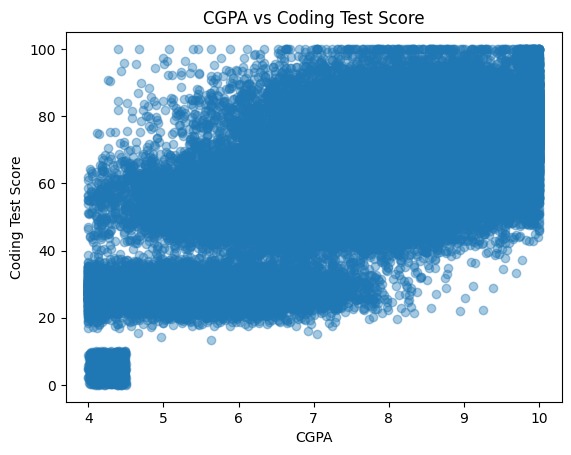

In [ ]:
plt.scatter(
    df["CGPA"],
    df["CodingTestScore"],
    alpha=0.4
)

plt.title("CGPA vs Coding Test Score")
plt.xlabel("CGPA")
plt.ylabel("Coding Test Score")
plt.show()

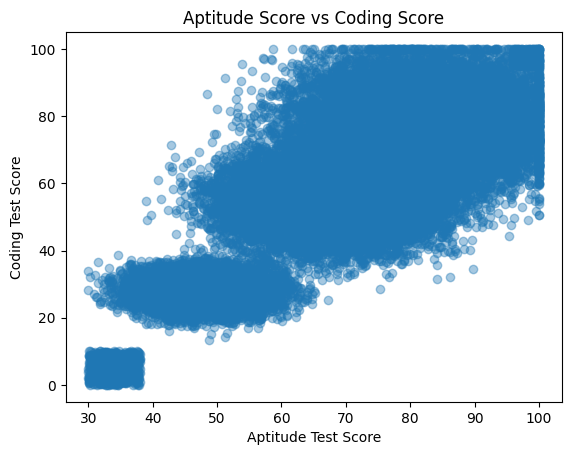

In [ ]:
plt.scatter(
    df["AptitudeTestScore"],
    df["CodingTestScore"],
    alpha=0.4
)

plt.title("Aptitude Score vs Coding Score")
plt.xlabel("Aptitude Test Score")
plt.ylabel("Coding Test Score")
plt.show()

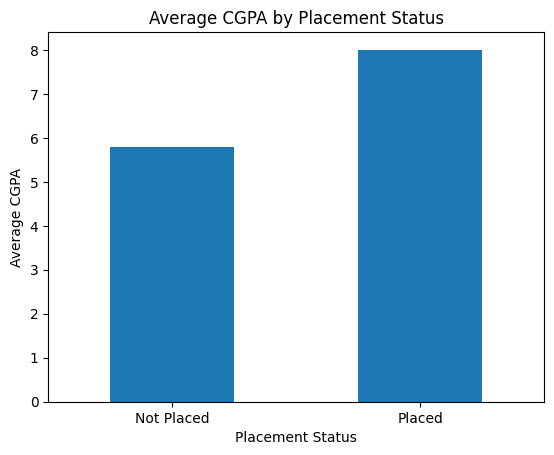

In [ ]:
average_cgpa = df.groupby("PlacementStatus")["CGPA"].mean()

average_cgpa.index = ["Not Placed", "Placed"]

average_cgpa.plot(kind="bar")

plt.title("Average CGPA by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Average CGPA")
plt.xticks(rotation=0)
plt.show()

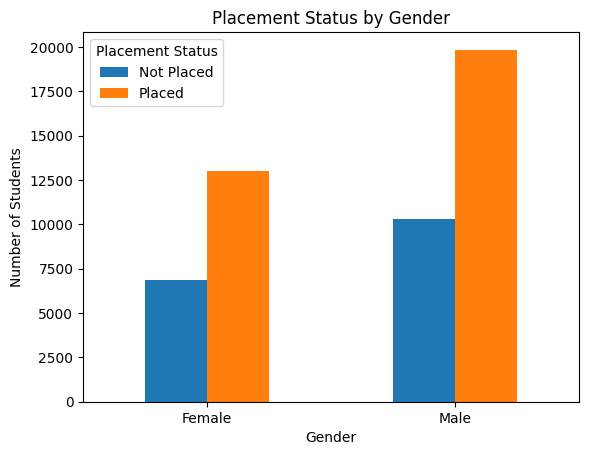

In [ ]:
gender_placement = pd.crosstab(
    df["Gender"],
    df["PlacementStatus"]
)

gender_placement.columns = ["Not Placed", "Placed"]

gender_placement.plot(kind="bar")

plt.title("Placement Status by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.legend(title="Placement Status")
plt.show()

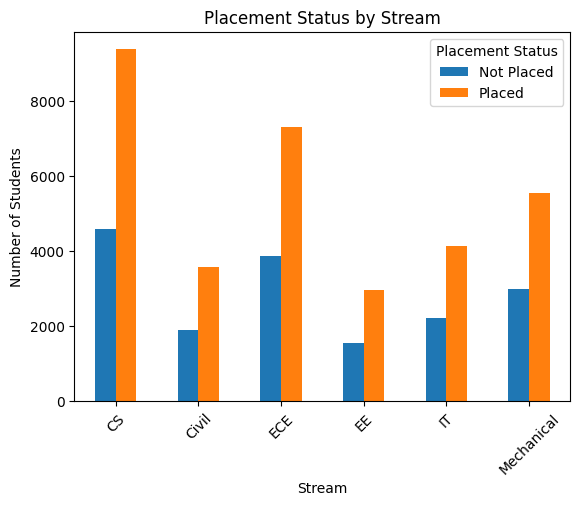

In [ ]:
stream_placement = pd.crosstab(
    df["Stream"],
    df["PlacementStatus"]
)

stream_placement.columns = ["Not Placed", "Placed"]

stream_placement.plot(kind="bar")

plt.title("Placement Status by Stream")
plt.xlabel("Stream")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)
plt.legend(title="Placement Status")
plt.show()

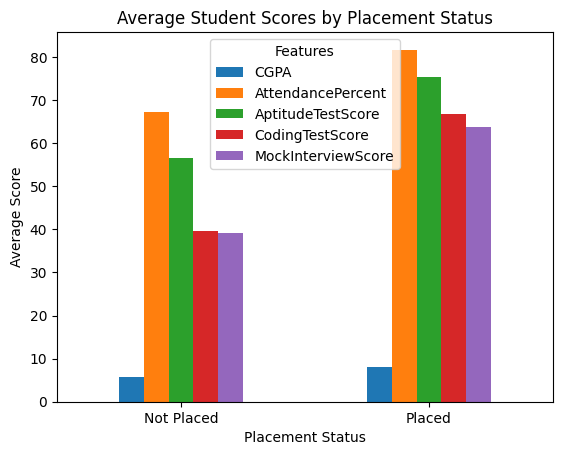

In [ ]:
score_columns = [
    "CGPA",
    "AttendancePercent",
    "AptitudeTestScore",
    "CodingTestScore",
    "MockInterviewScore"
]

average_scores = df.groupby("PlacementStatus")[score_columns].mean()

average_scores.index = ["Not Placed", "Placed"]

average_scores.plot(kind="bar")

plt.title("Average Student Scores by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Features")
plt.show()

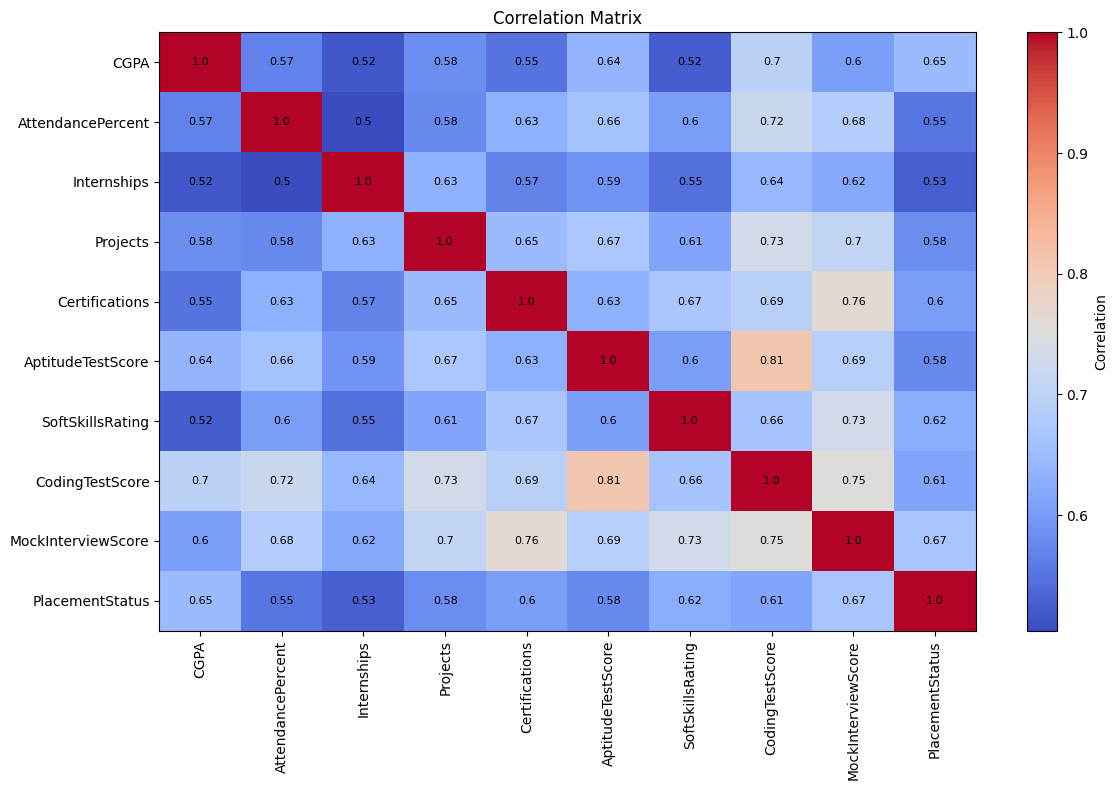

In [ ]:
important_columns = [
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Certifications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore",
    "PlacementStatus"
]

correlation = df[important_columns].corr()

plt.figure(figsize=(12, 8))

plt.imshow(
    correlation,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(important_columns)),
    important_columns,
    rotation=90
)

plt.yticks(
    range(len(important_columns)),
    important_columns
)

plt.title("Correlation Matrix")

for i in range(len(important_columns)):
    for j in range(len(important_columns)):
        plt.text(
            j,
            i,
            round(correlation.iloc[i, j], 2),
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

Dataset loaded successfully
Dataset shape: (50000, 31)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,2,0,66.7,2.2,49.4,47.8,0,Low,0,0
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,1,0,48.2,2.4,26.7,25.8,0,Low,0,0
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,1,0,73.8,2.8,67.7,41.5,0,Low,1,0
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,2,0,69.8,2.7,66.9,48.0,0,Mid,1,0
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,4,1,73.1,2.1,71.7,61.7,1,High,1,0


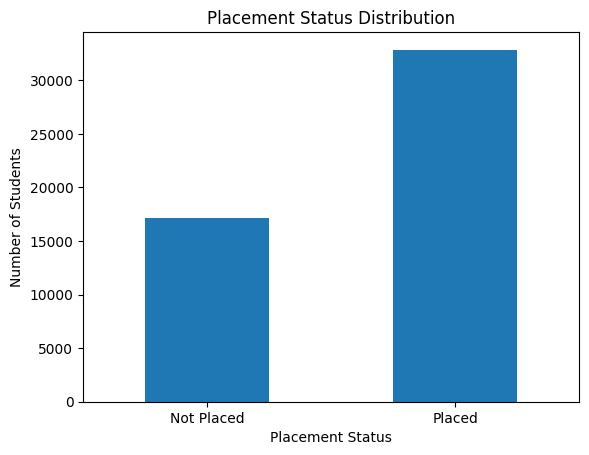

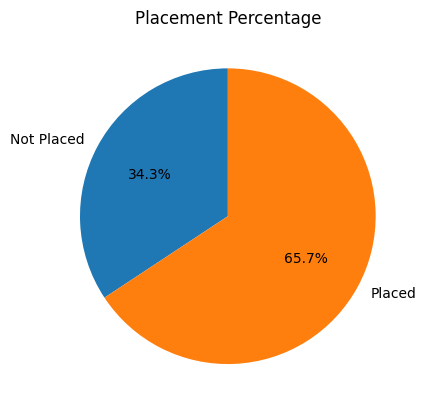

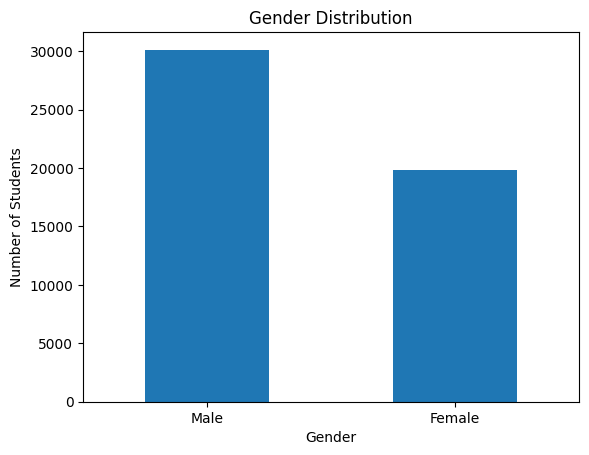

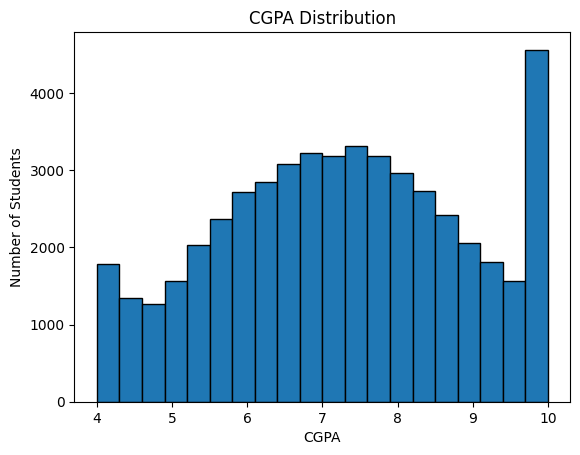

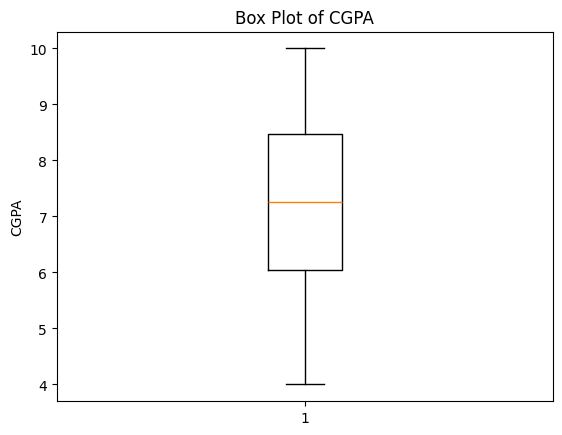

/tmp/ipykernel_663/356030130.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


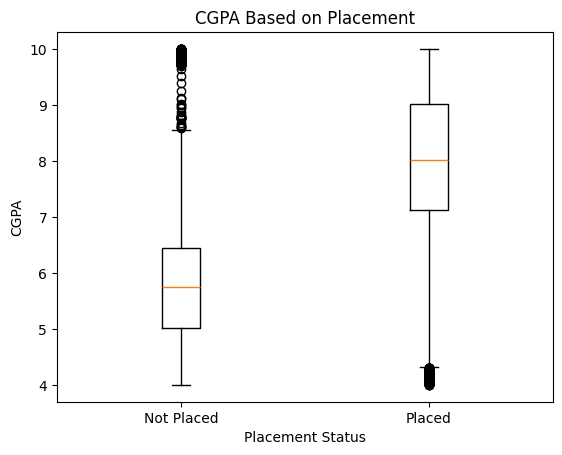

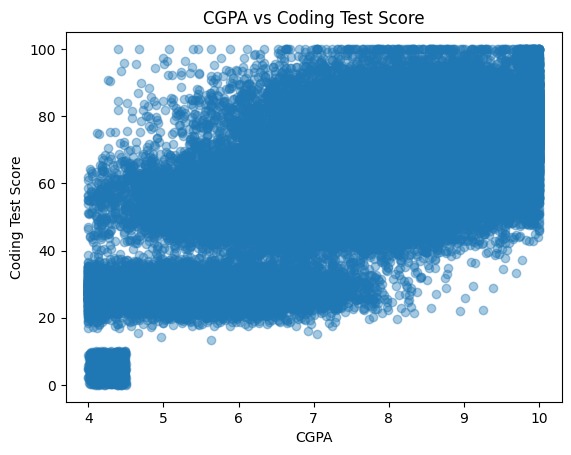

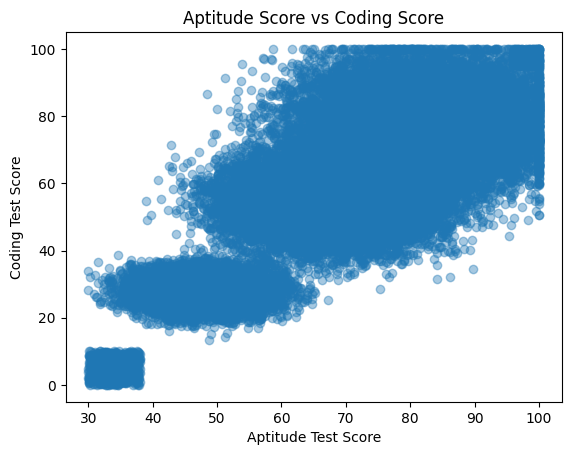

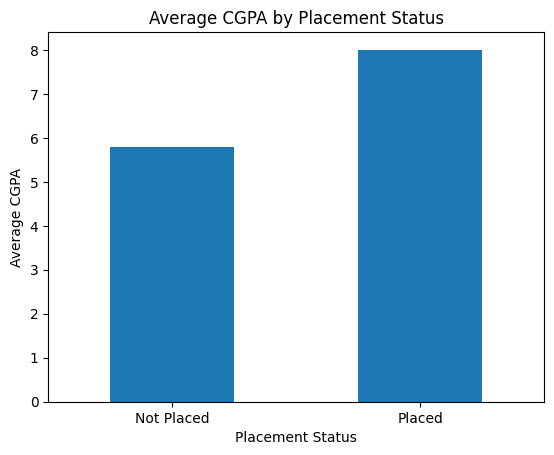

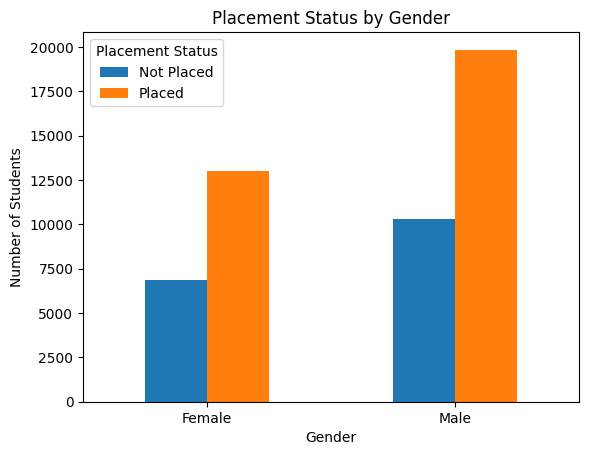

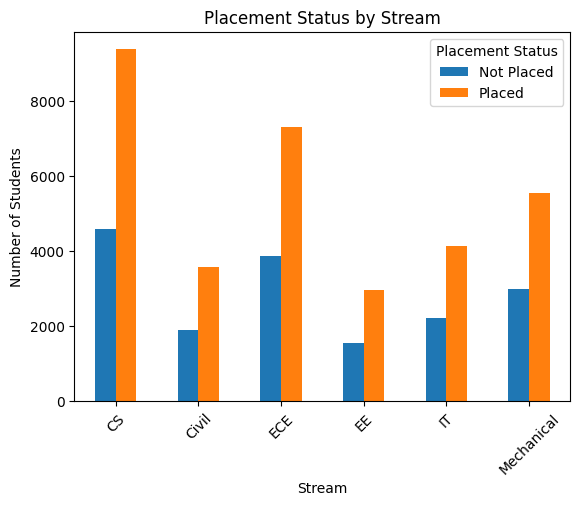

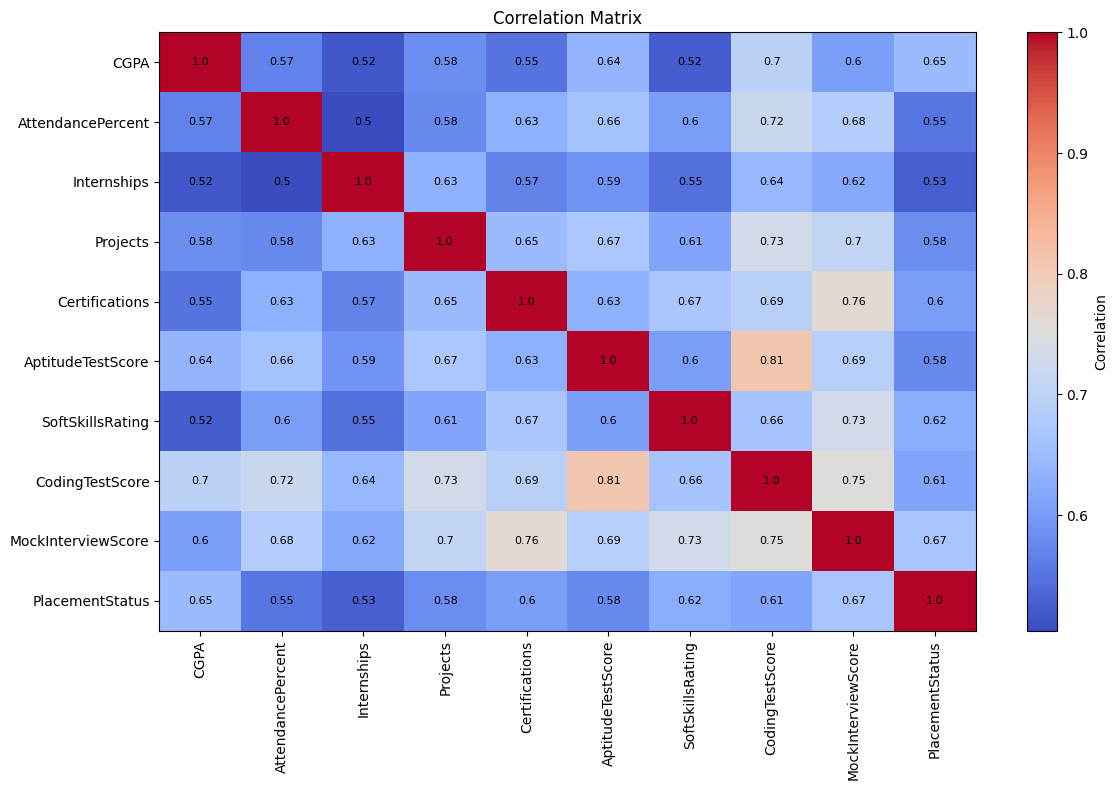

All graphs created successfully


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# 1. READ CSV FILE
# ==========================================================

df = pd.read_csv("/content/placement_predict_50k Dataset.csv")

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

display(df.head())


# ==========================================================
# 2. PLACEMENT BAR GRAPH
# ==========================================================

placement_counts = df["PlacementStatus"].value_counts().sort_index()
placement_counts.index = ["Not Placed", "Placed"]

placement_counts.plot(kind="bar")

plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()


# ==========================================================
# 3. PLACEMENT PIE CHART
# ==========================================================

plt.pie(
    placement_counts,
    labels=placement_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Placement Percentage")
plt.show()


# ==========================================================
# 4. GENDER BAR GRAPH
# ==========================================================

df["Gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()


# ==========================================================
# 5. CGPA HISTOGRAM
# ==========================================================

plt.hist(
    df["CGPA"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title("CGPA Distribution")
plt.xlabel("CGPA")
plt.ylabel("Number of Students")
plt.show()


# ==========================================================
# 6. CGPA BOX PLOT
# ==========================================================

plt.boxplot(df["CGPA"].dropna())

plt.title("Box Plot of CGPA")
plt.ylabel("CGPA")
plt.show()


# ==========================================================
# 7. CGPA BY PLACEMENT
# ==========================================================

not_placed_cgpa = df[df["PlacementStatus"] == 0]["CGPA"].dropna()
placed_cgpa = df[df["PlacementStatus"] == 1]["CGPA"].dropna()

plt.boxplot(
    [not_placed_cgpa, placed_cgpa],
    labels=["Not Placed", "Placed"]
)

plt.title("CGPA Based on Placement")
plt.xlabel("Placement Status")
plt.ylabel("CGPA")
plt.show()


# ==========================================================
# 8. CGPA VS CODING SCORE
# ==========================================================

plt.scatter(
    df["CGPA"],
    df["CodingTestScore"],
    alpha=0.4
)

plt.title("CGPA vs Coding Test Score")
plt.xlabel("CGPA")
plt.ylabel("Coding Test Score")
plt.show()


# ==========================================================
# 9. APTITUDE VS CODING SCORE
# ==========================================================

plt.scatter(
    df["AptitudeTestScore"],
    df["CodingTestScore"],
    alpha=0.4
)

plt.title("Aptitude Score vs Coding Score")
plt.xlabel("Aptitude Test Score")
plt.ylabel("Coding Test Score")
plt.show()


# ==========================================================
# 10. AVERAGE CGPA BY PLACEMENT
# ==========================================================

average_cgpa = df.groupby("PlacementStatus")["CGPA"].mean()
average_cgpa.index = ["Not Placed", "Placed"]

average_cgpa.plot(kind="bar")

plt.title("Average CGPA by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Average CGPA")
plt.xticks(rotation=0)
plt.show()


# ==========================================================
# 11. PLACEMENT BY GENDER
# ==========================================================

gender_placement = pd.crosstab(
    df["Gender"],
    df["PlacementStatus"]
)

gender_placement.columns = ["Not Placed", "Placed"]

gender_placement.plot(kind="bar")

plt.title("Placement Status by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.legend(title="Placement Status")
plt.show()


# ==========================================================
# 12. PLACEMENT BY STREAM
# ==========================================================

stream_placement = pd.crosstab(
    df["Stream"],
    df["PlacementStatus"]
)

stream_placement.columns = ["Not Placed", "Placed"]

stream_placement.plot(kind="bar")

plt.title("Placement Status by Stream")
plt.xlabel("Stream")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)
plt.legend(title="Placement Status")
plt.show()


# ==========================================================
# 13. CORRELATION MATRIX
# ==========================================================

important_columns = [
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Certifications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore",
    "PlacementStatus"
]

correlation = df[important_columns].corr()

plt.figure(figsize=(12, 8))

plt.imshow(
    correlation,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(important_columns)),
    important_columns,
    rotation=90
)

plt.yticks(
    range(len(important_columns)),
    important_columns
)

plt.title("Correlation Matrix")

for i in range(len(important_columns)):
    for j in range(len(important_columns)):
        plt.text(
            j,
            i,
            round(correlation.iloc[i, j], 2),
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

print("All graphs created successfully")

In [122]:
import os
import shutil
import pandas as pd

# ==========================================================
# 1. CREATE A FOLDER
# ==========================================================

folder_path = "/content/placement_project"

os.makedirs(folder_path, exist_ok=True)

print("Folder created:", folder_path)


# ==========================================================
# 2. SAVE THE DATASET
# ==========================================================

dataset_output = os.path.join(
    folder_path,
    "placement_dataset.csv"
)

df.to_csv(
    dataset_output,
    index=False
)

print("Dataset saved")


# ==========================================================
# 3. SAVE THE TRAINED MODEL
# ==========================================================

# Run this only if placement_model is already trained.

import joblib

model_output = os.path.join(
    folder_path,
    "placement_prediction_model.pkl"
)

joblib.dump(
    placement_model,
    model_output
)

print("Model saved")


# ==========================================================
# 4. SAVE MODEL RESULTS
# ==========================================================

results_file = os.path.join(
    folder_path,
    "model_results.txt"
)

with open(results_file, "w") as file:
    file.write("PLACEMENT PREDICTION MODEL RESULTS\n")
    file.write("=" * 50 + "\n")

    file.write(
        f"Training Accuracy: {training_accuracy * 100:.2f}%\n"
    )

    file.write(
        f"Testing Accuracy: {testing_accuracy * 100:.2f}%\n\n"
    )

    file.write("Classification Report:\n")

    file.write(
        classification_report(
            y_test,
            y_prediction,
            zero_division=0
        )
    )

print("Model results saved")


# ==========================================================
# 5. SAVE CONFUSION MATRIX
# ==========================================================

confusion_output = os.path.join(
    folder_path,
    "confusion_matrix.csv"
)

confusion_df.to_csv(confusion_output)

print("Confusion matrix saved")


# ==========================================================
# 6. CREATE ZIP FILE
# ==========================================================

zip_path = "/content/placement_project"

shutil.make_archive(
    zip_path,
    "zip",
    folder_path
)

print("ZIP file created successfully")
print("ZIP location:", zip_path + ".zip")


# ==========================================================
# 7. DOWNLOAD ZIP FILE
# ==========================================================

from google.colab import files

files.download(
    "/content/placement_project.zip"
)

Folder created: /content/placement_project
Dataset saved
Model saved
Model results saved
Confusion matrix saved
ZIP file created successfully
ZIP location: /content/placement_project.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dataset loaded successfully
Rows: 50000
Columns: 31


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,2,0,66.7,2.2,49.4,47.8,0,Low,0,0
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,1,0,48.2,2.4,26.7,25.8,0,Low,0,0
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,1,0,73.8,2.8,67.7,41.5,0,Low,1,0
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,2,0,69.8,2.7,66.9,48.0,0,Mid,1,0
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,4,1,73.1,2.1,71.7,61.7,1,High,1,0


Graph folder created: /content/placement_all_graphs


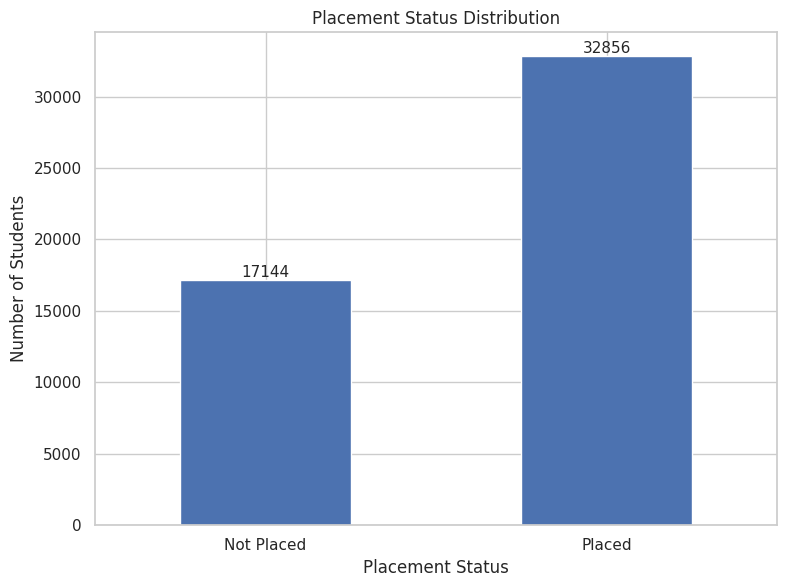

Saved: 01_placement_status_bar.png


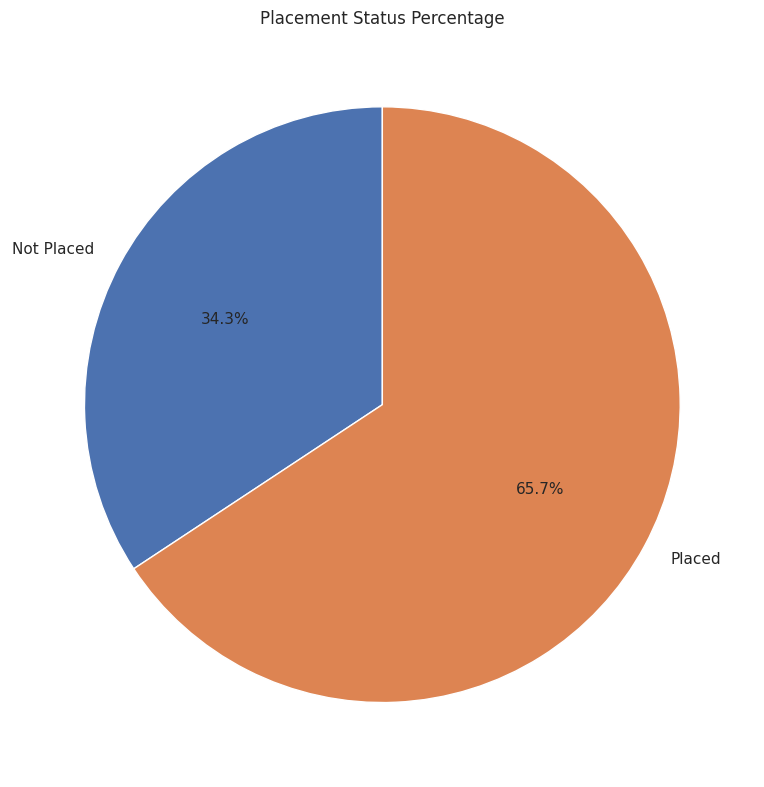

Saved: 02_placement_status_pie.png


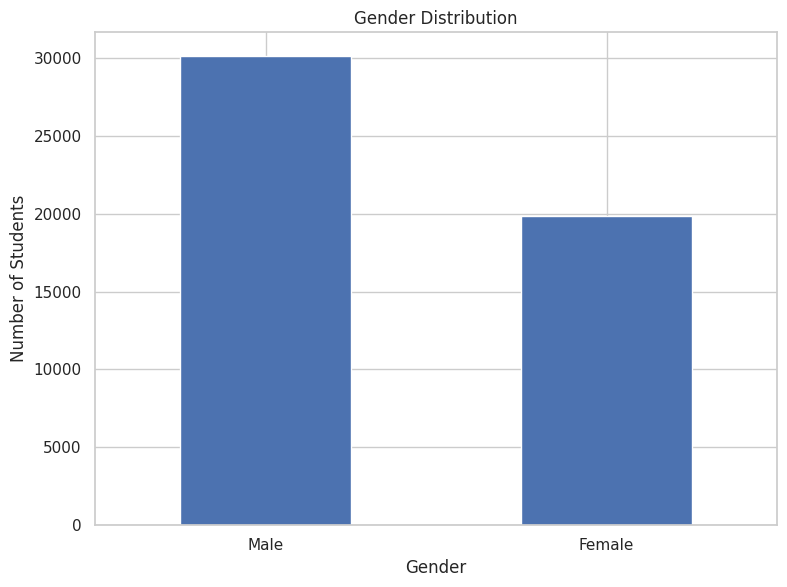

Saved: 03_gender_distribution.png


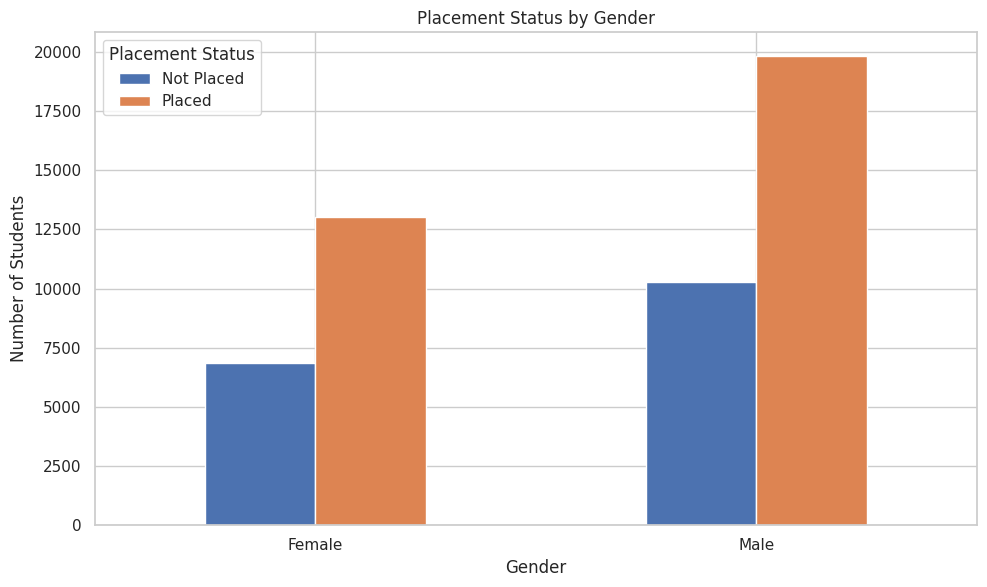

Saved: 04_placement_by_gender.png


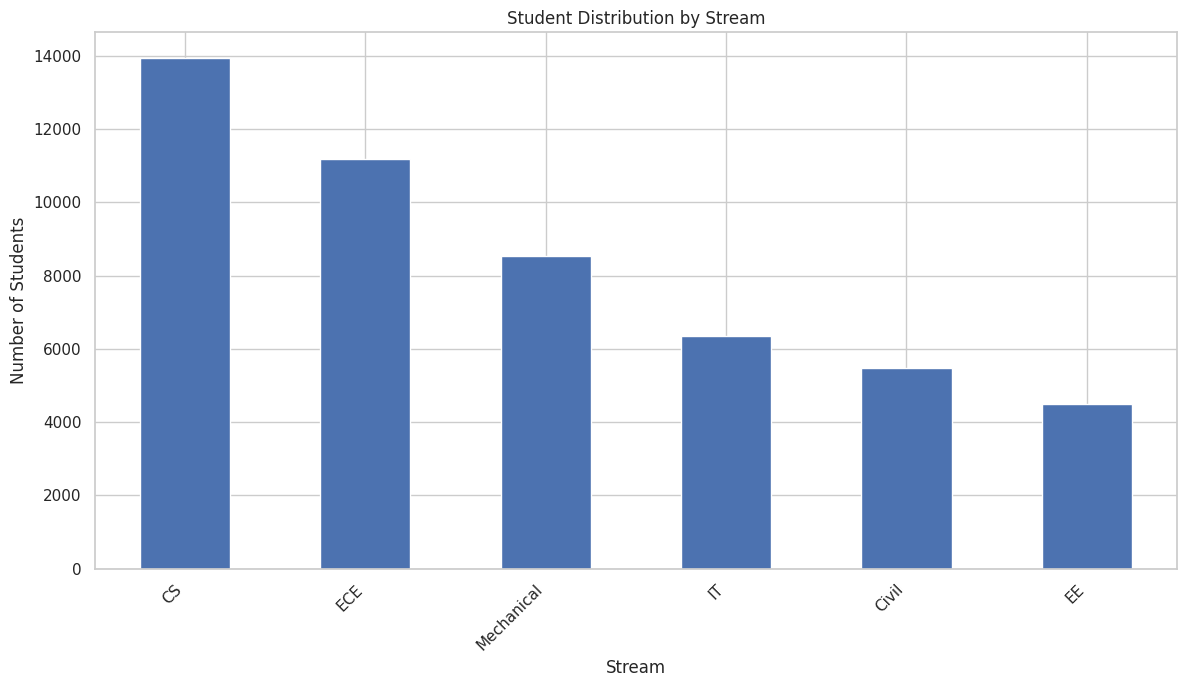

Saved: 05_stream_distribution.png


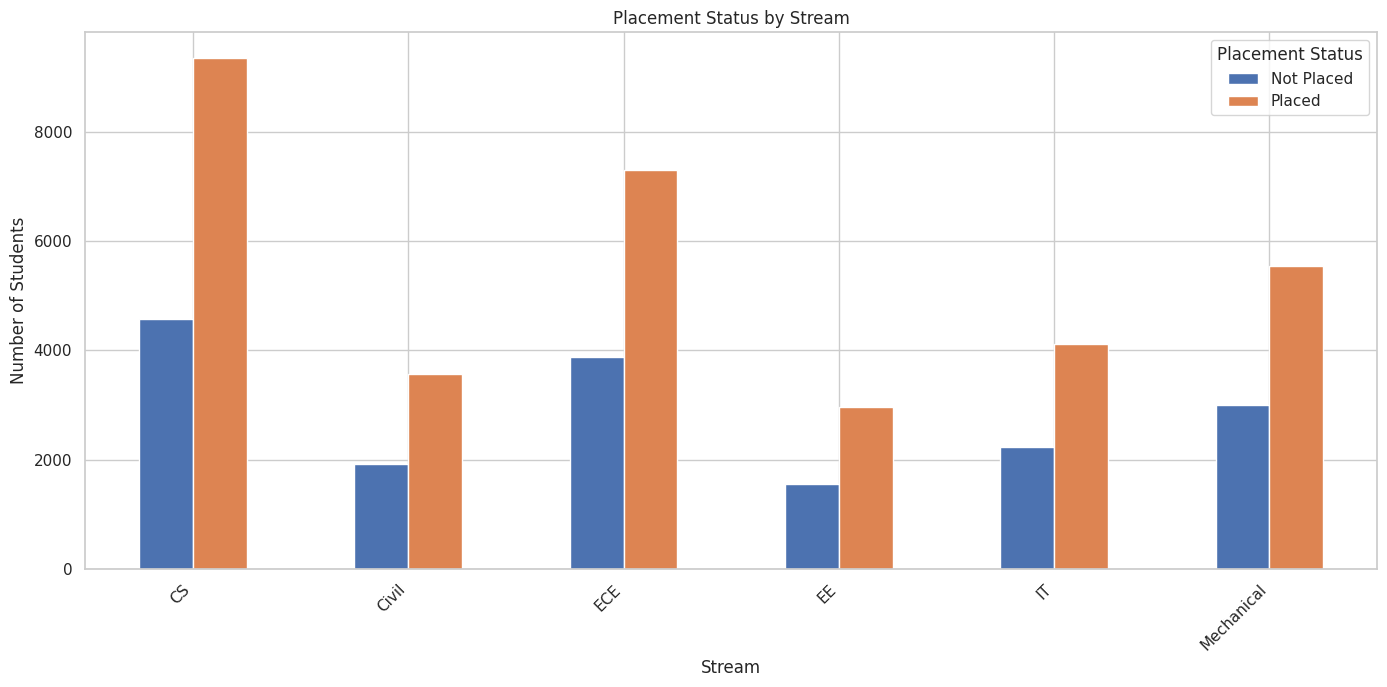

Saved: 06_placement_by_stream.png


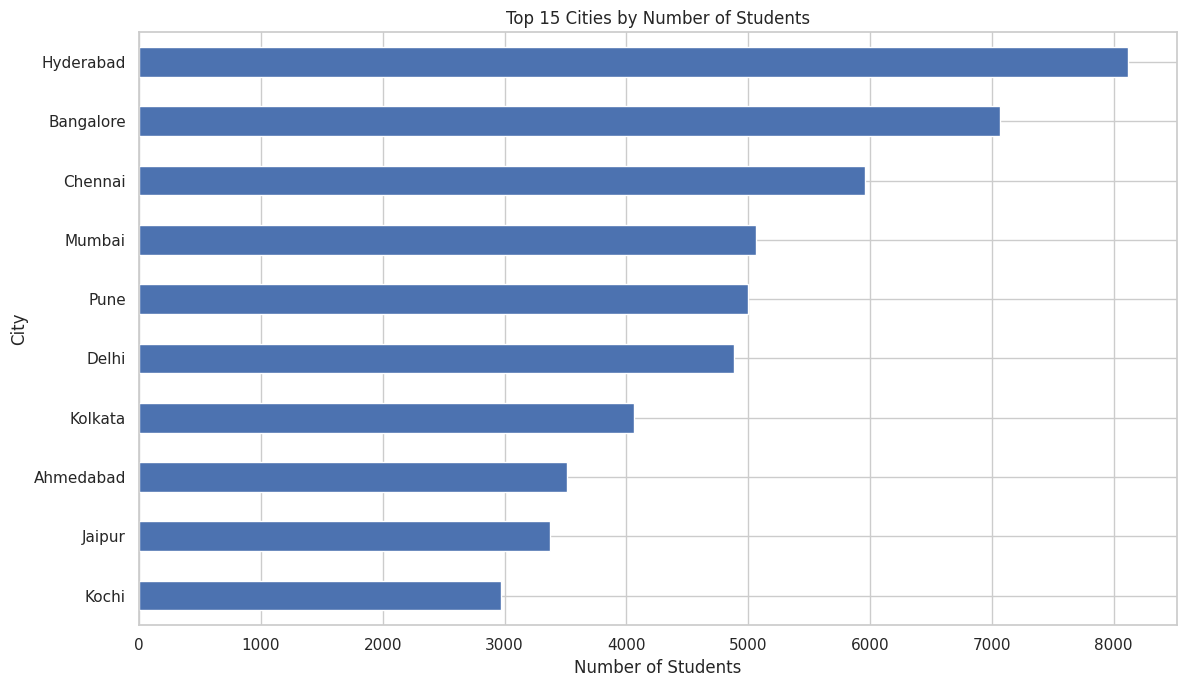

Saved: 07_top_15_cities.png


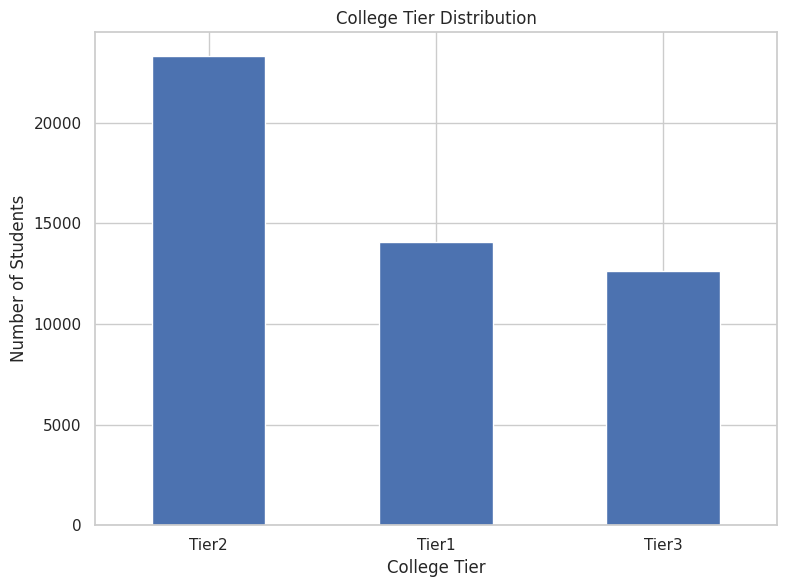

Saved: 08_college_tier_distribution.png


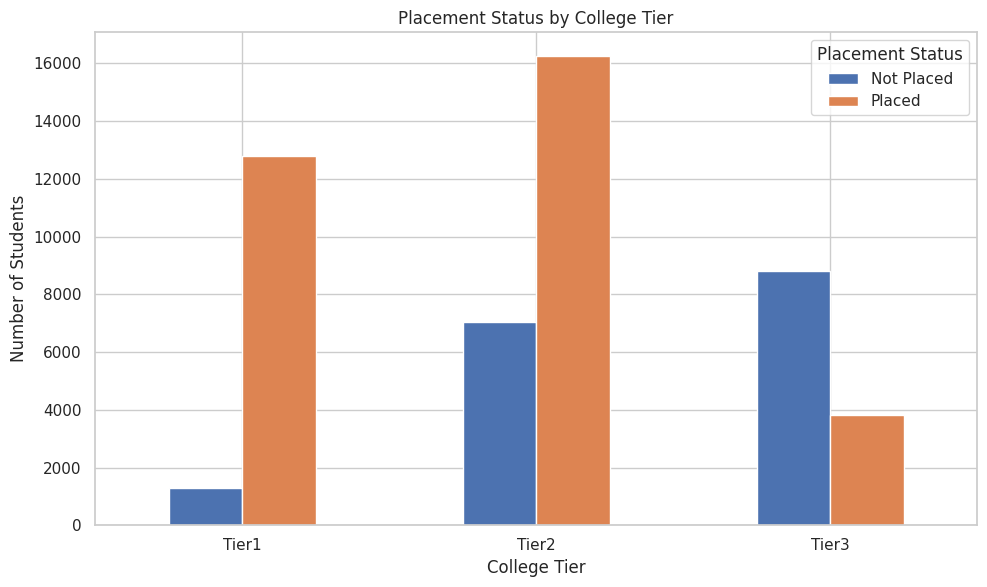

Saved: 09_placement_by_college_tier.png


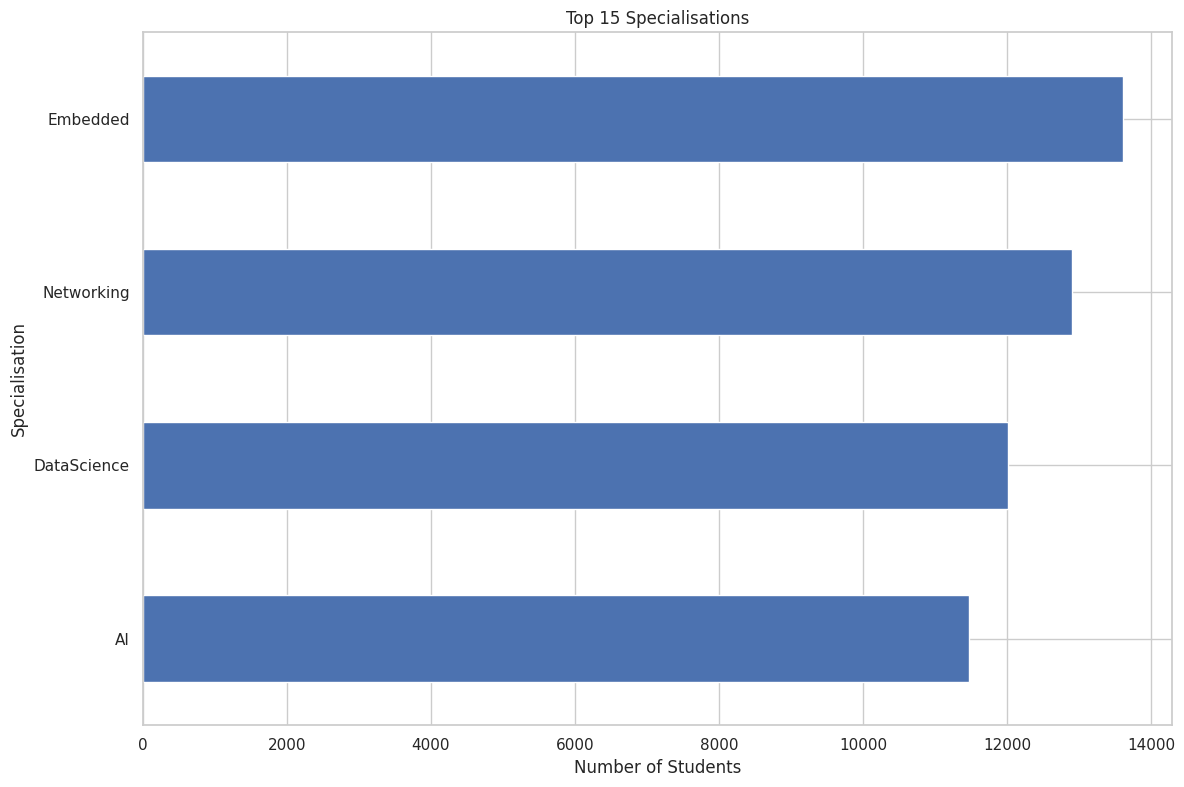

Saved: 10_top_15_specialisations.png


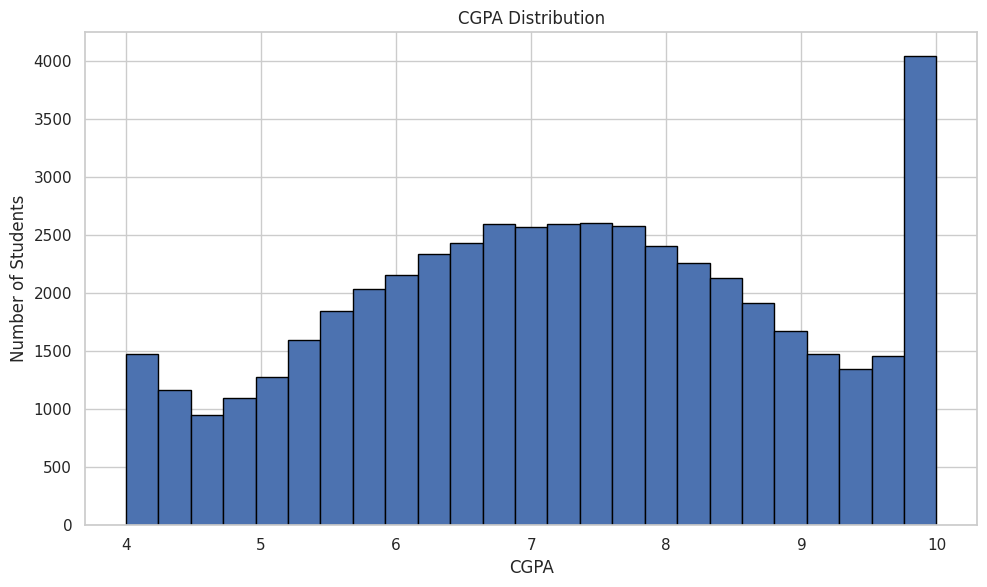

Saved: 11_cgpa_histogram.png


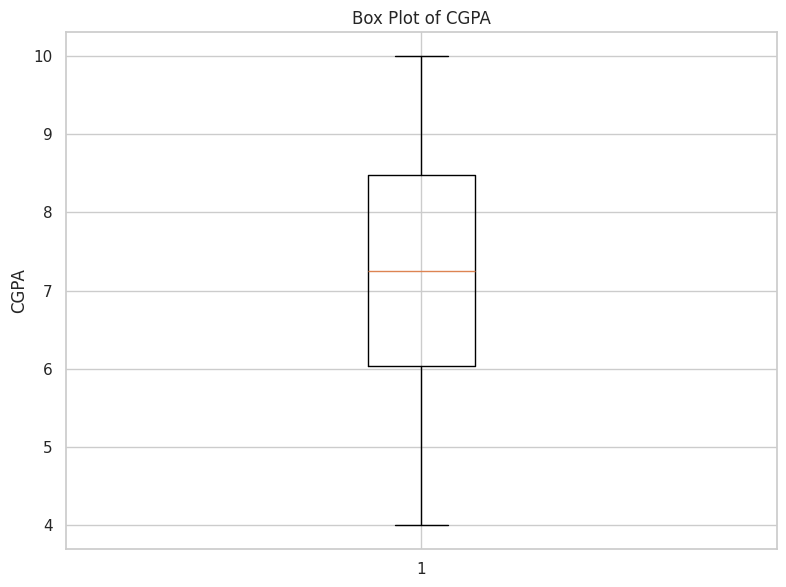

Saved: 12_cgpa_boxplot.png


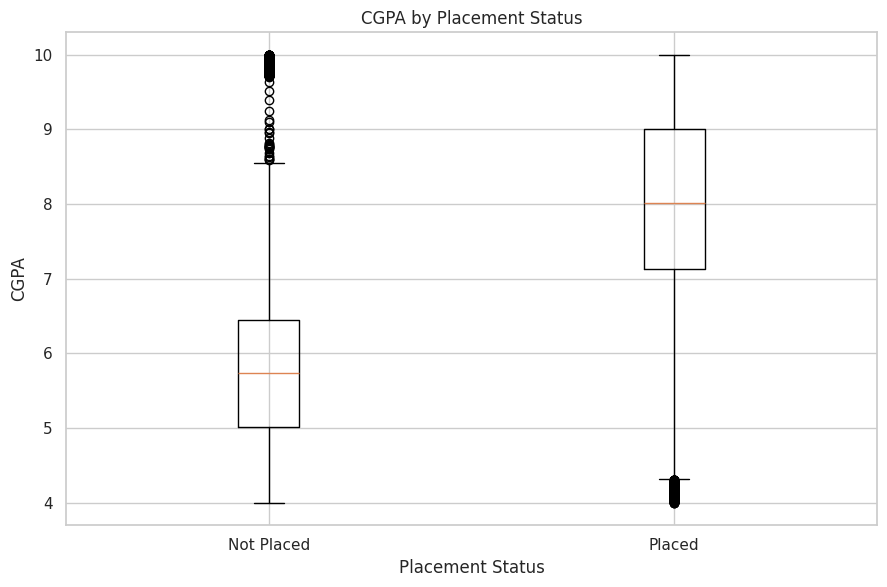

Saved: 13_cgpa_by_placement.png


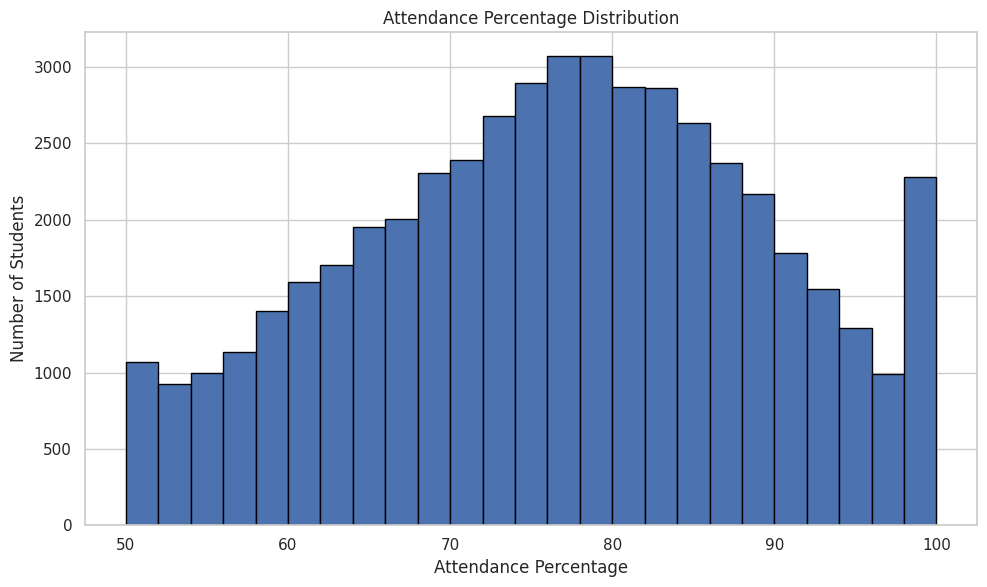

Saved: 14_attendance_histogram.png


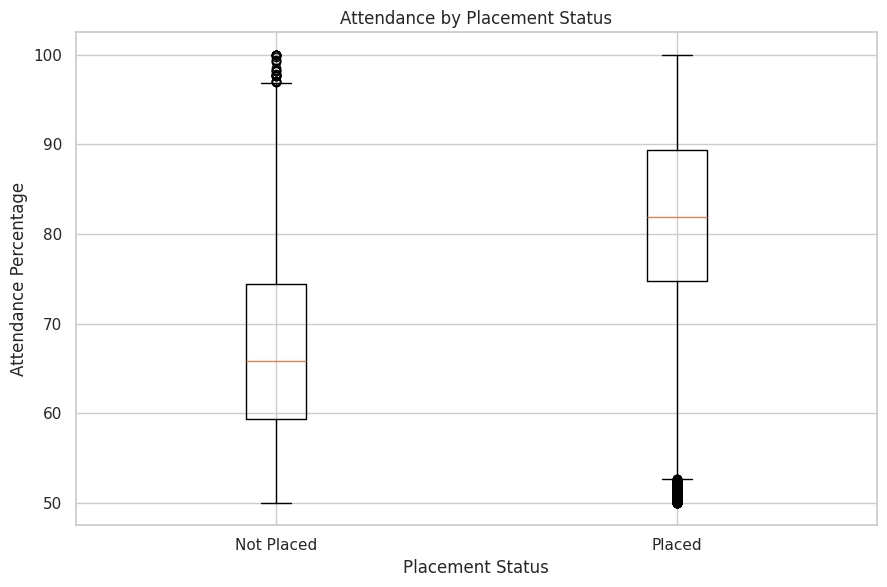

Saved: 15_attendance_by_placement.png


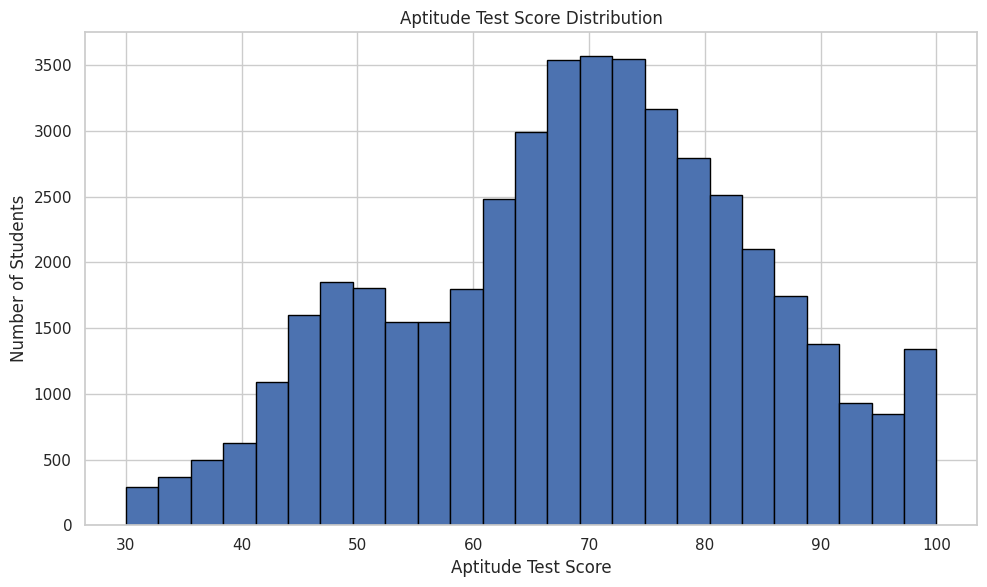

Saved: 16_aptitude_score_histogram.png


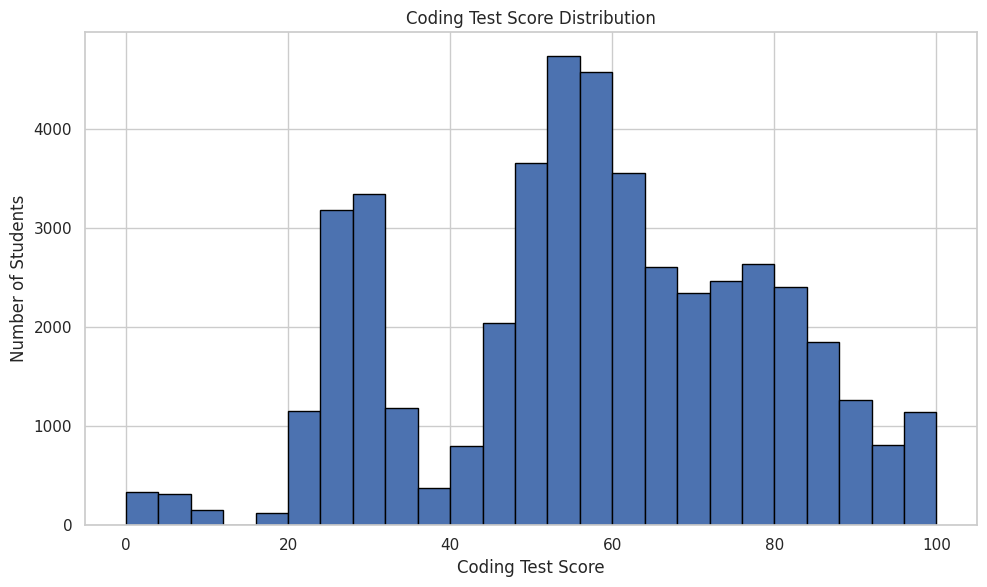

Saved: 17_coding_score_histogram.png


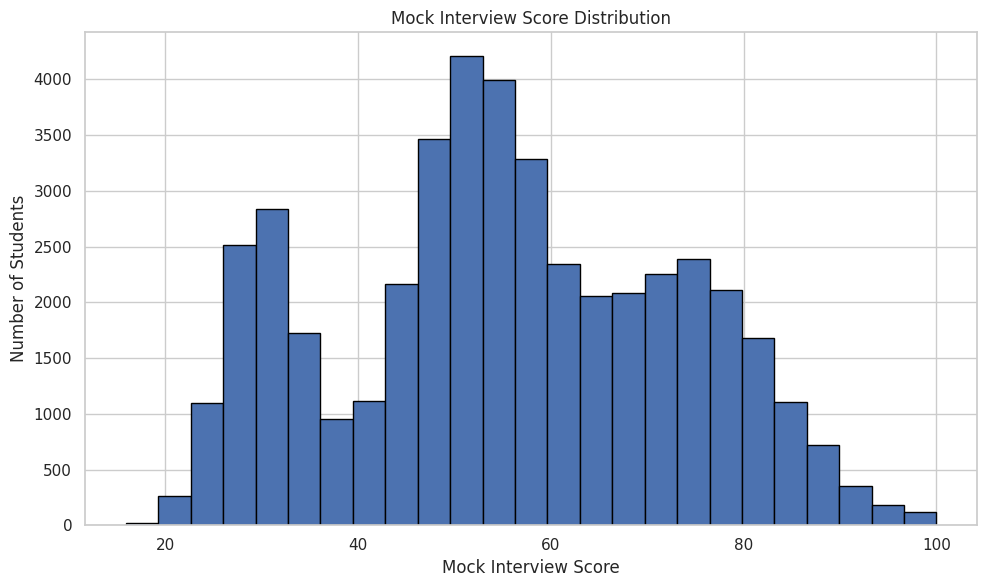

Saved: 18_mock_interview_histogram.png


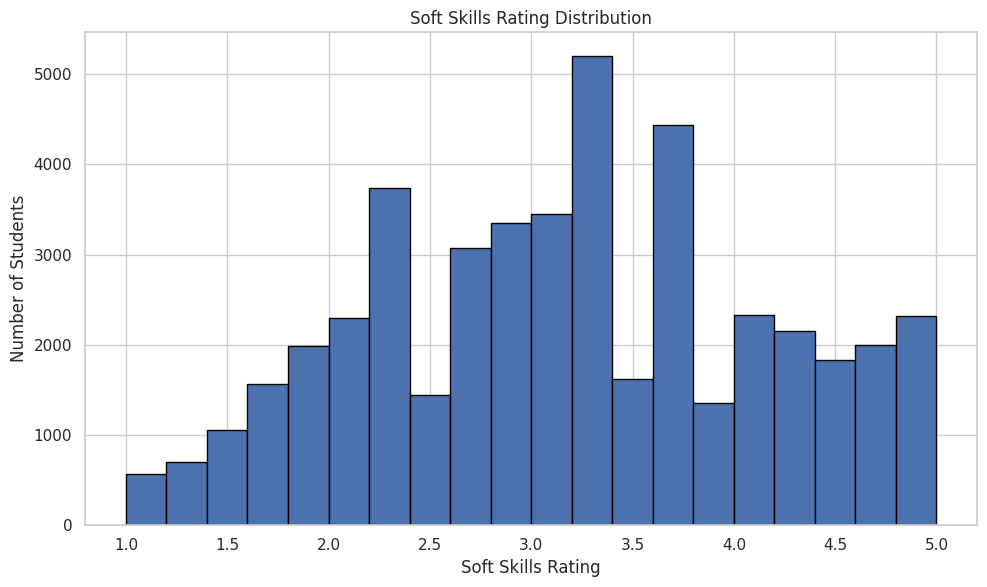

Saved: 19_soft_skills_histogram.png


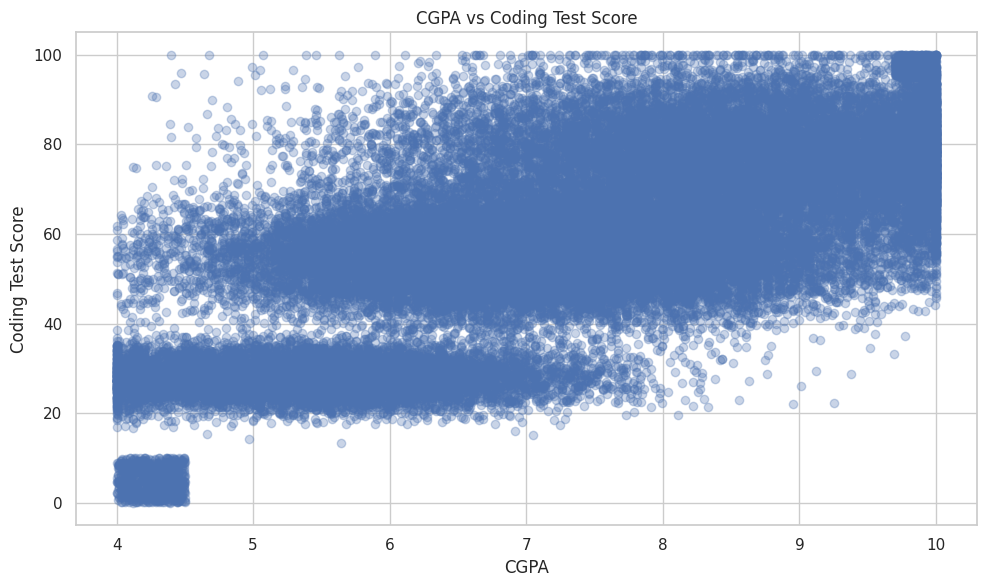

Saved: 20_cgpa_vs_coding_score.png


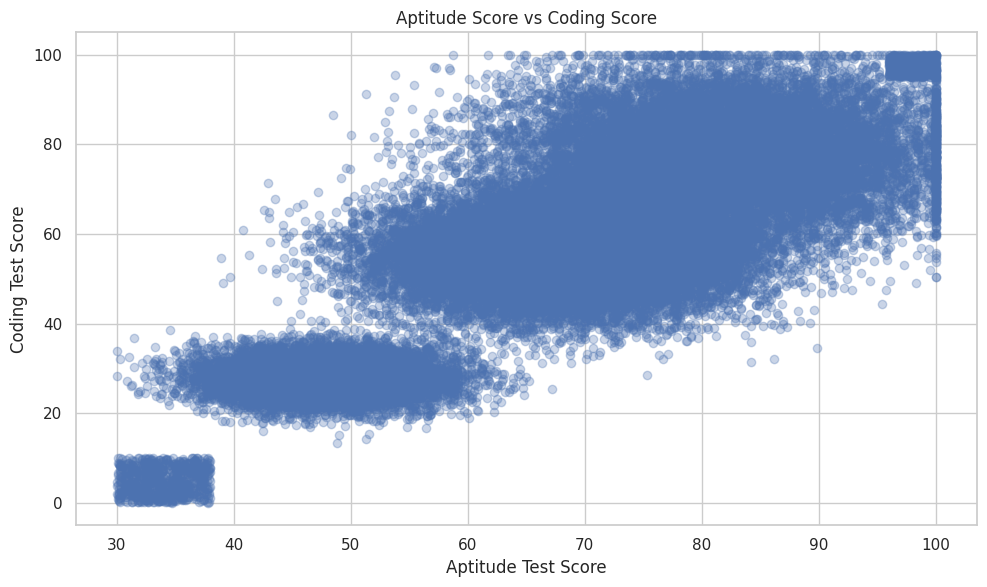

Saved: 21_aptitude_vs_coding_score.png


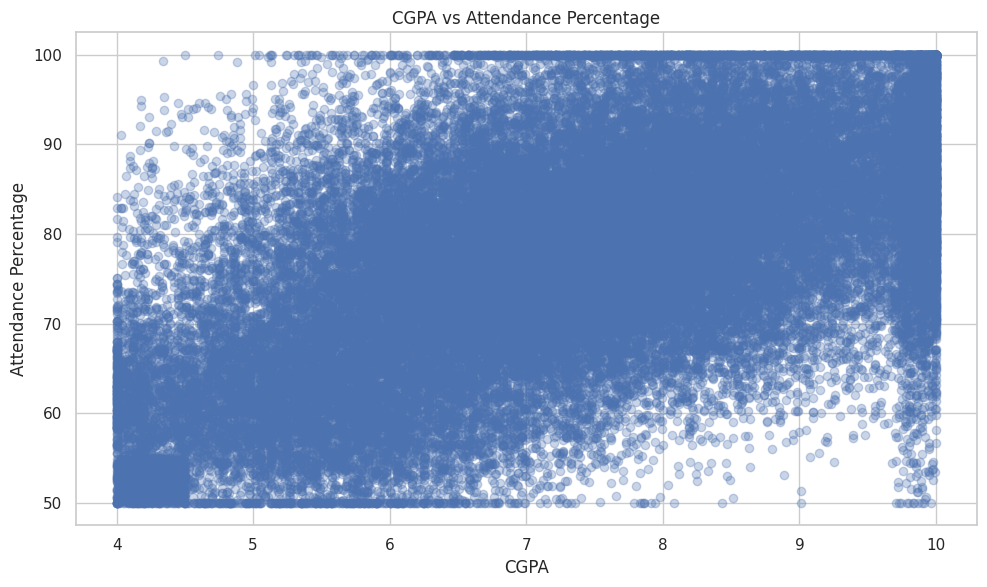

Saved: 22_cgpa_vs_attendance.png


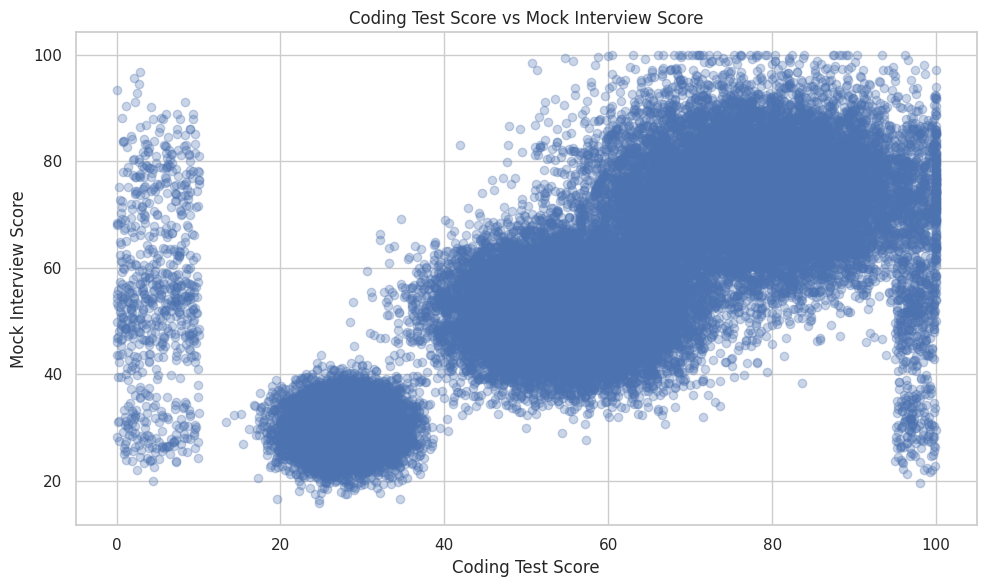

Saved: 23_coding_vs_mock_interview.png


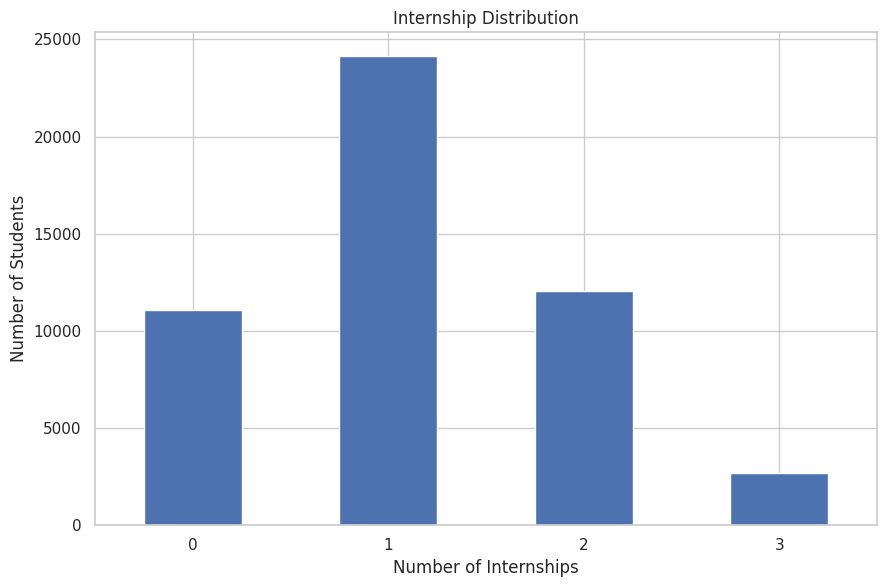

Saved: 24_internship_distribution.png


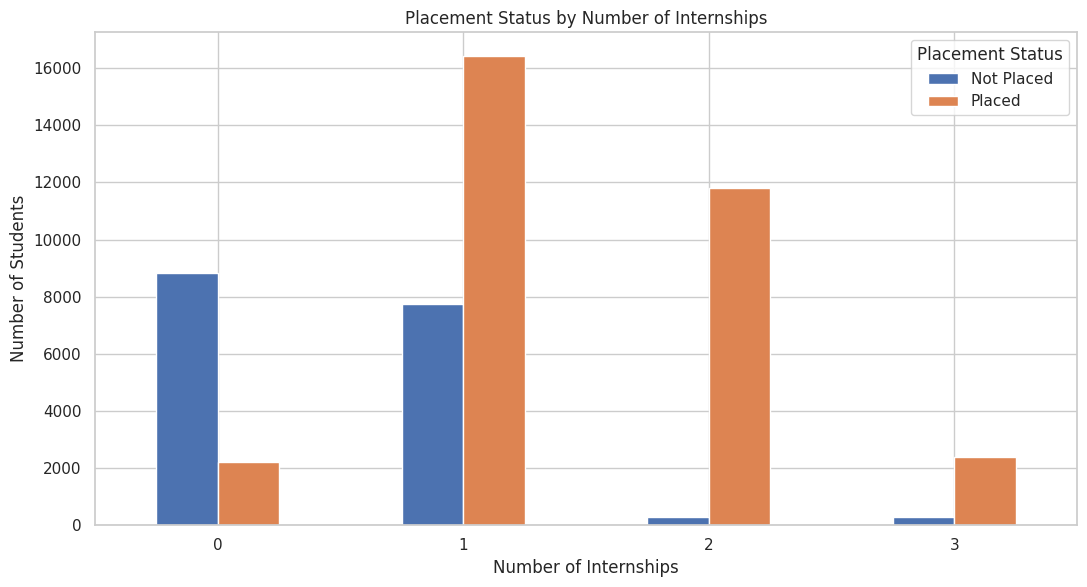

Saved: 25_placement_by_internships.png


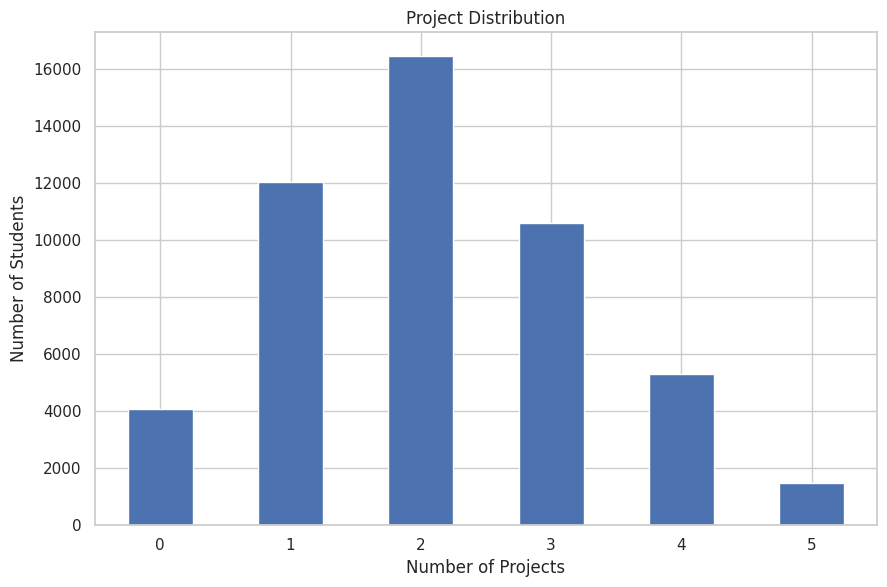

Saved: 26_project_distribution.png


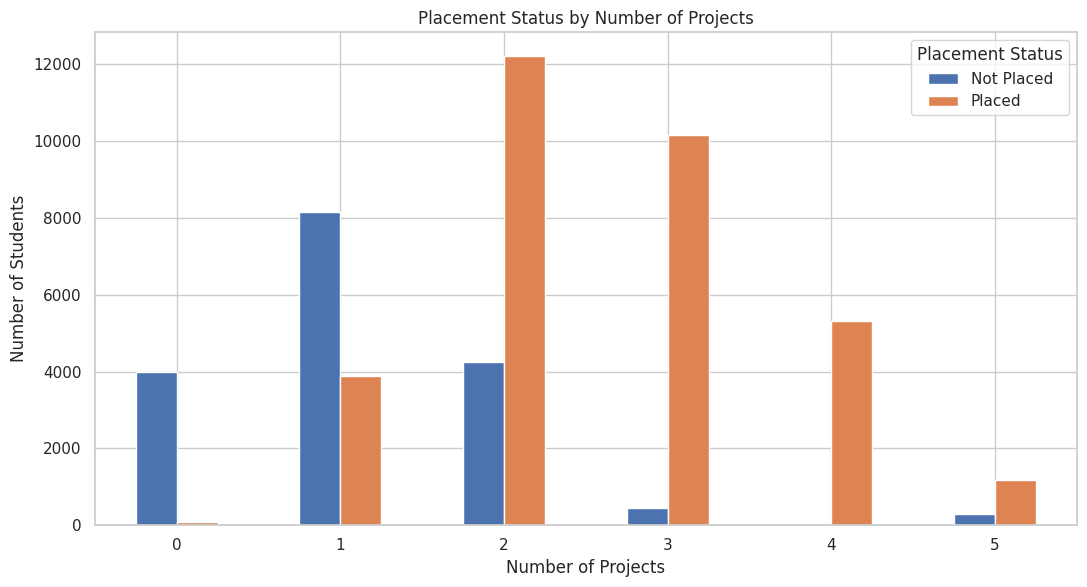

Saved: 27_placement_by_projects.png


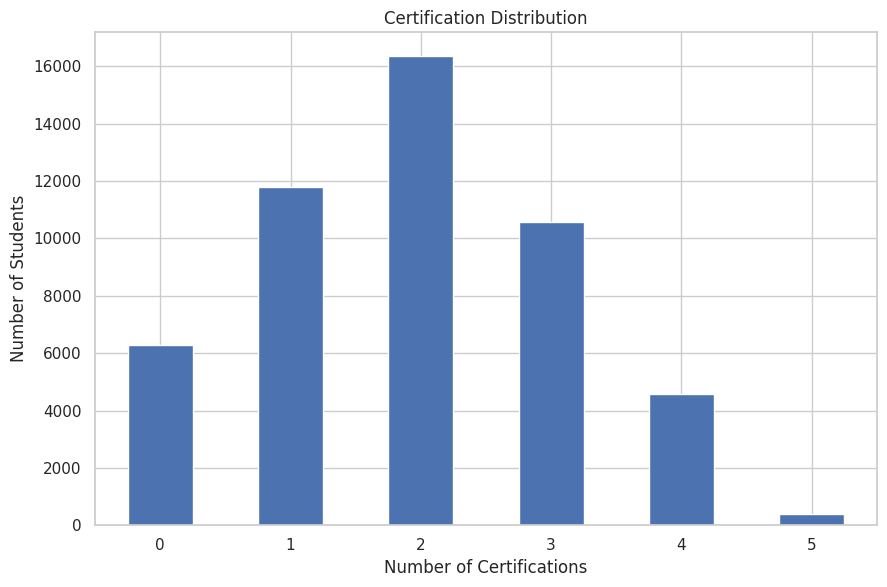

Saved: 28_certification_distribution.png


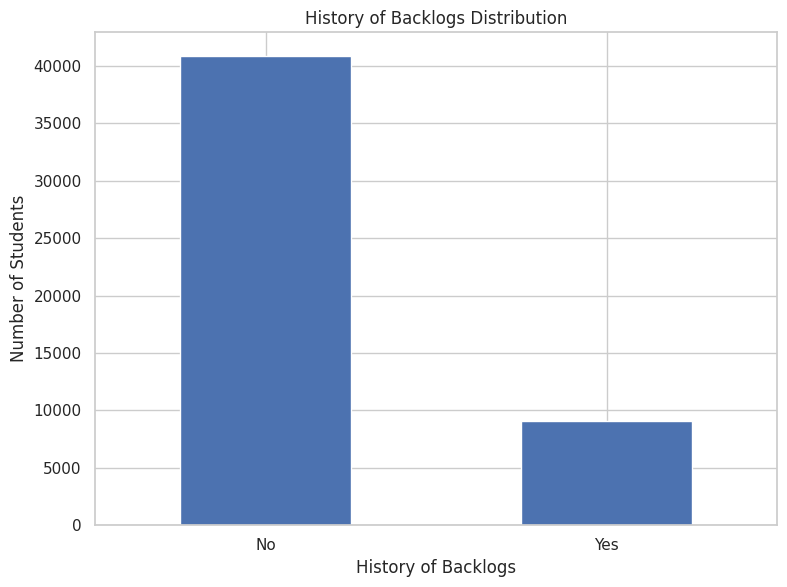

Saved: 29_backlog_distribution.png


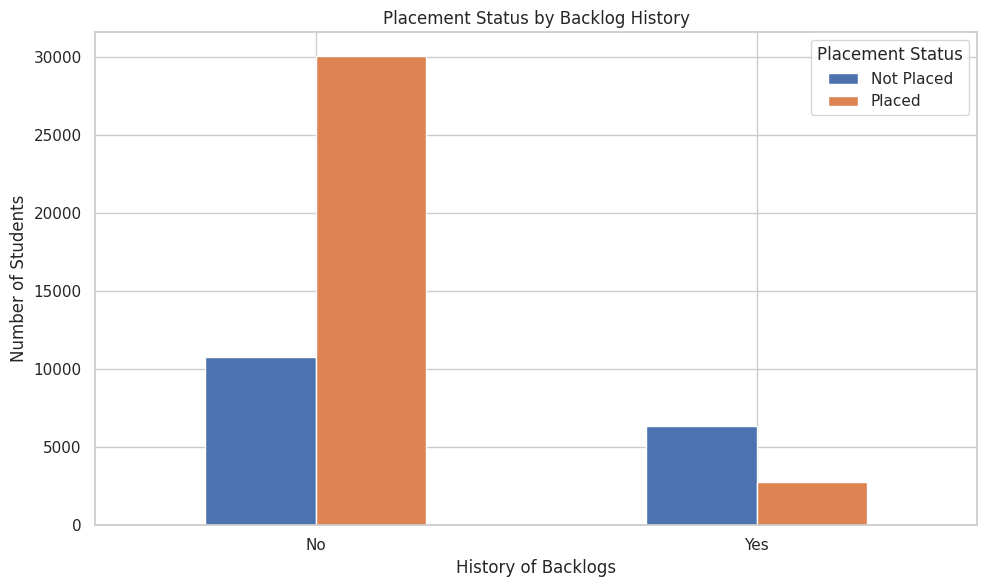

Saved: 30_placement_by_backlogs.png


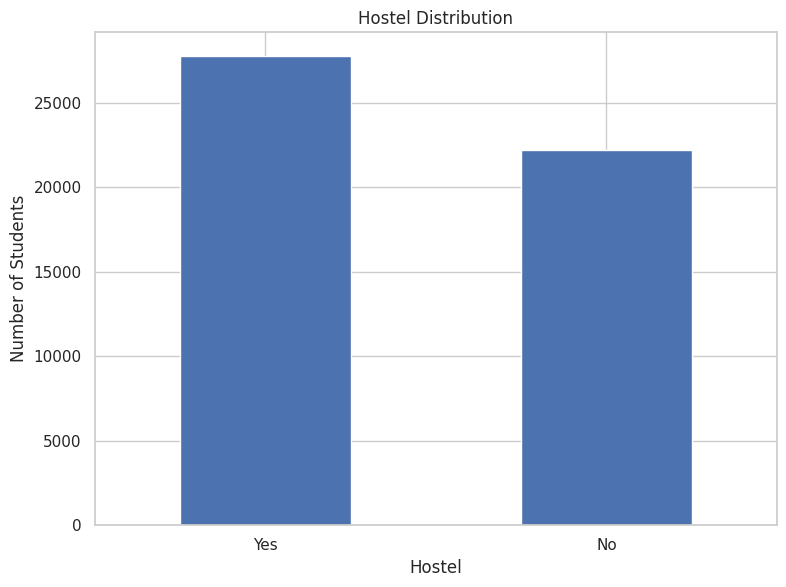

Saved: 31_hostel_distribution.png


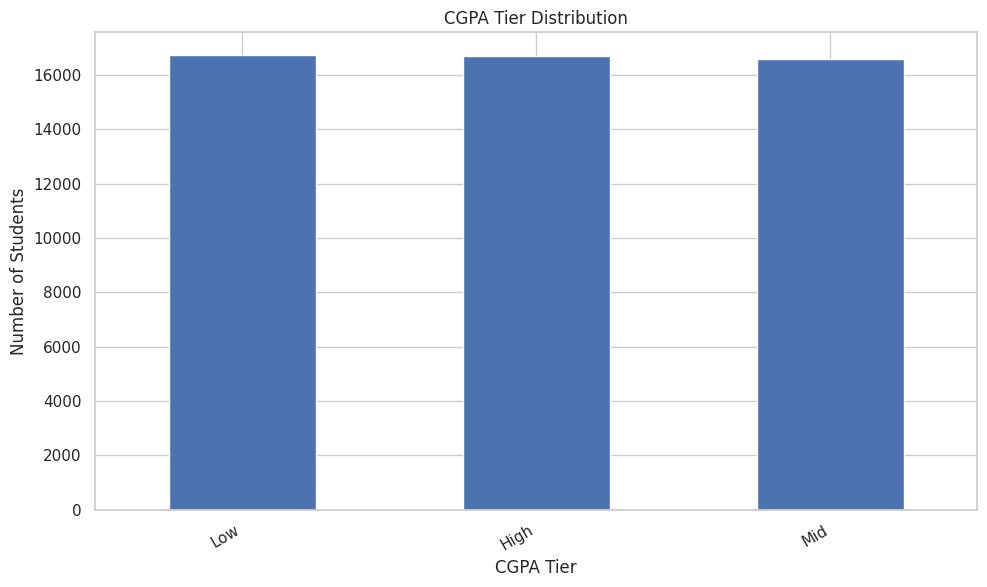

Saved: 32_cgpa_tier_distribution.png


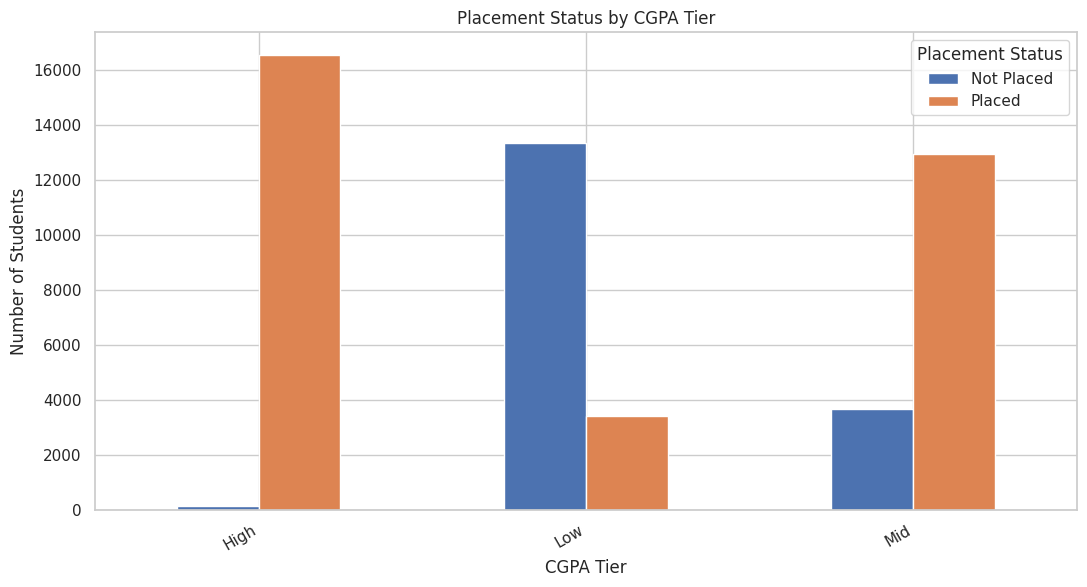

Saved: 33_placement_by_cgpa_tier.png


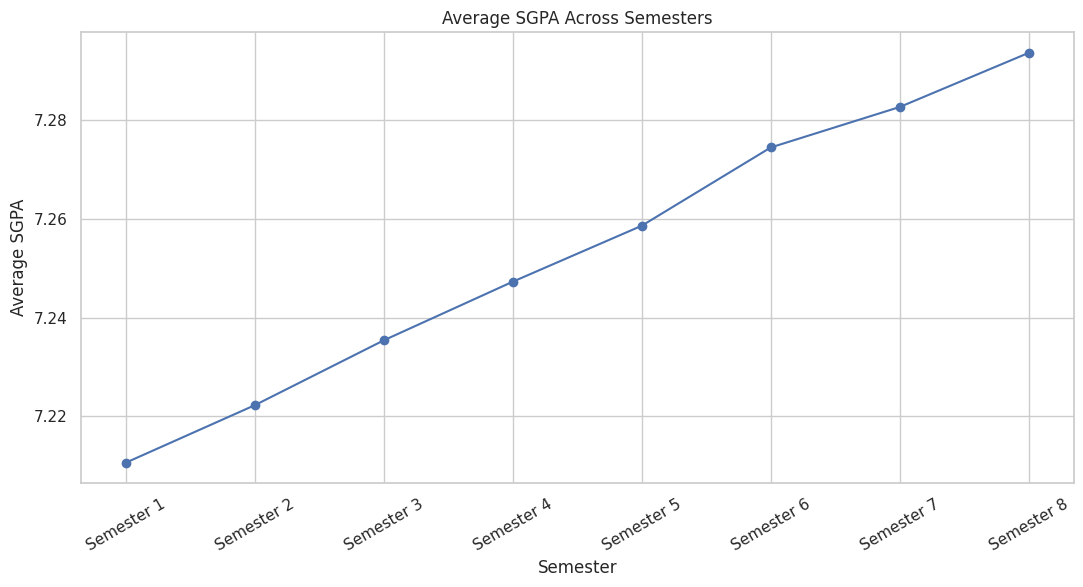

Saved: 34_average_semester_sgpa.png


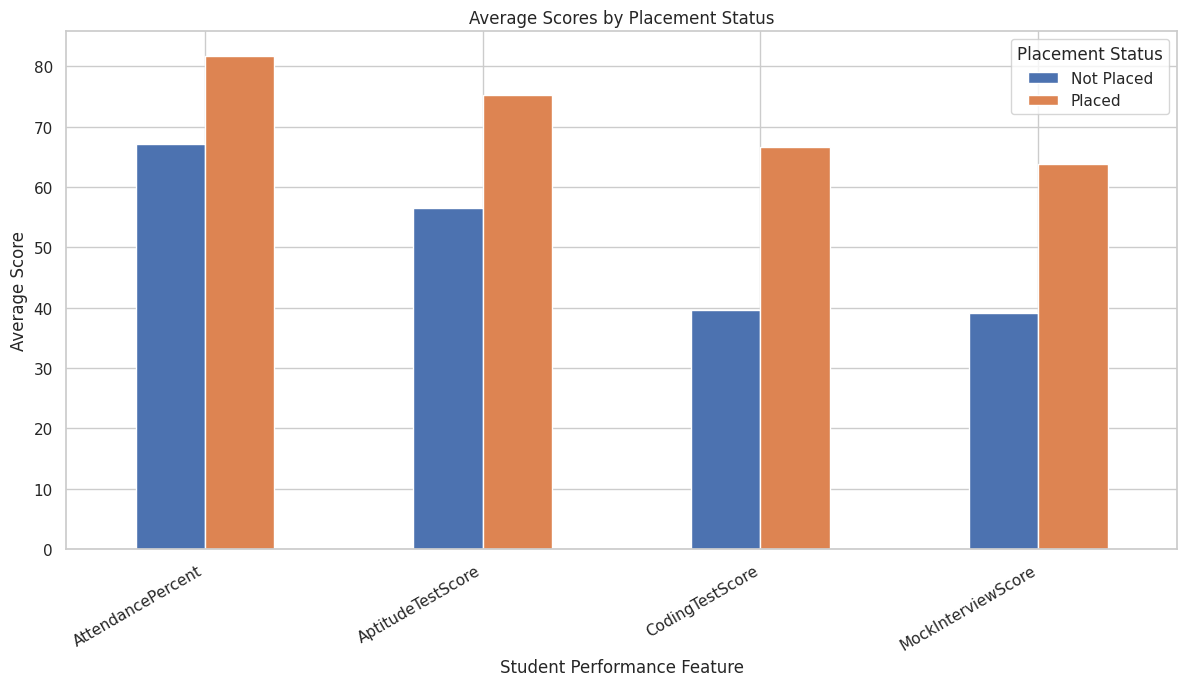

Saved: 35_average_scores_by_placement.png


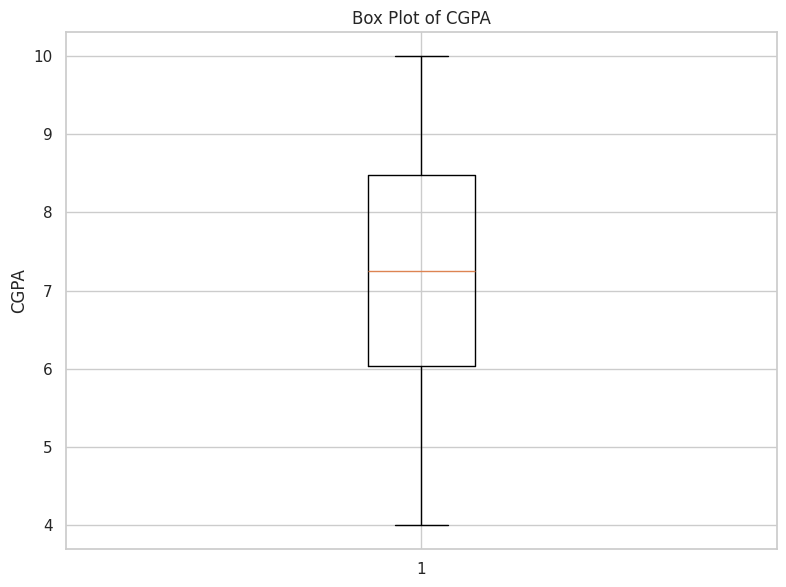

Saved: 36_boxplot_CGPA.png


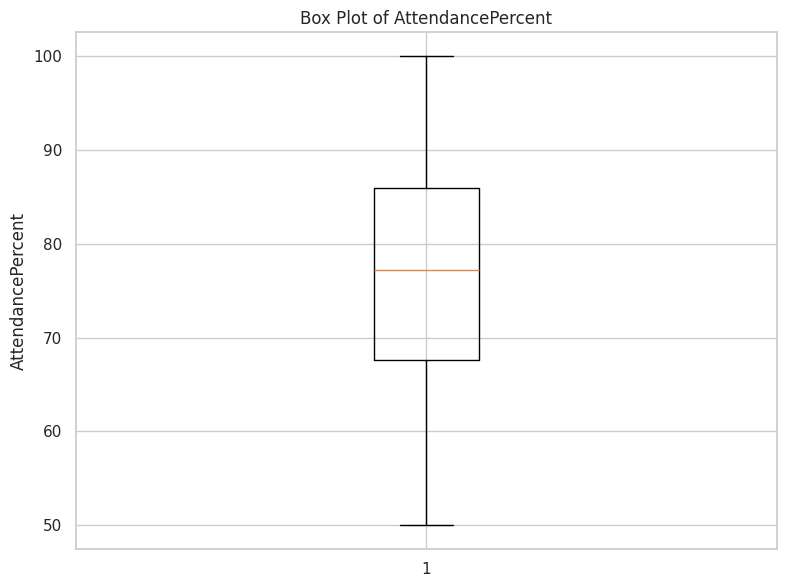

Saved: 37_boxplot_AttendancePercent.png


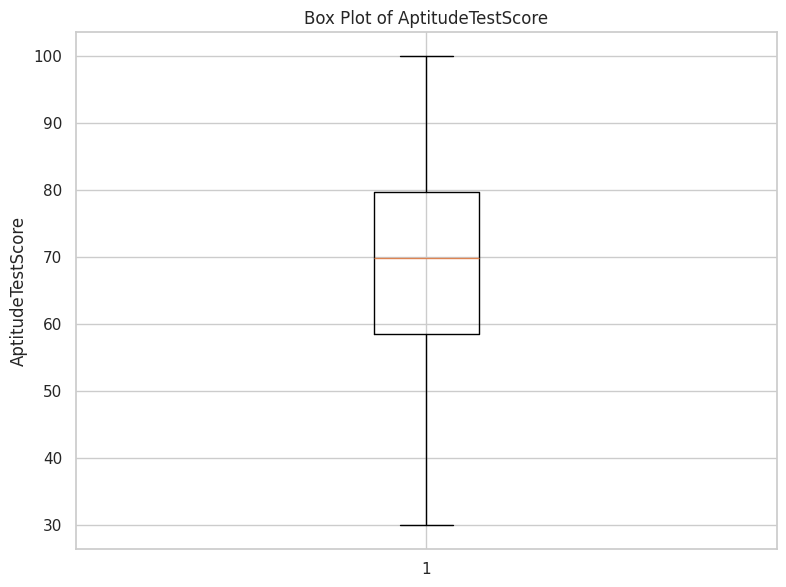

Saved: 38_boxplot_AptitudeTestScore.png


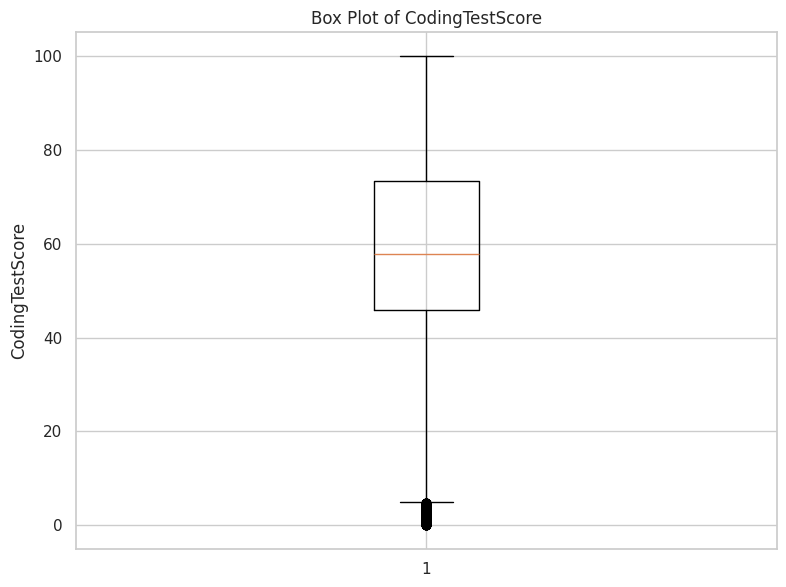

Saved: 39_boxplot_CodingTestScore.png


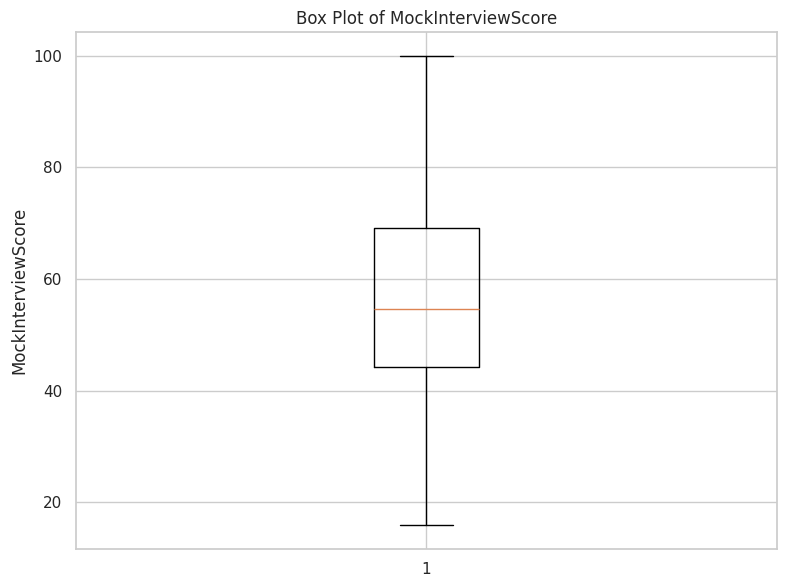

Saved: 40_boxplot_MockInterviewScore.png


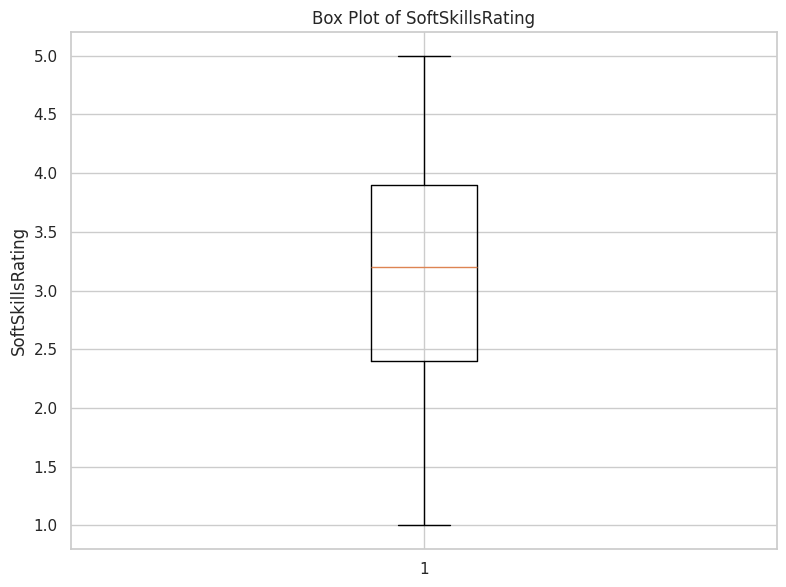

Saved: 41_boxplot_SoftSkillsRating.png


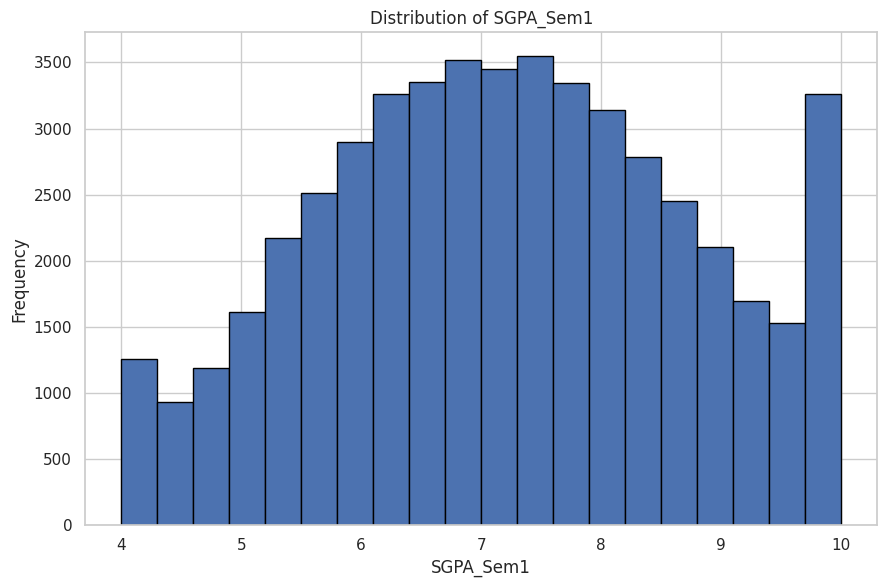

Saved: 42_histogram_SGPA_Sem1.png


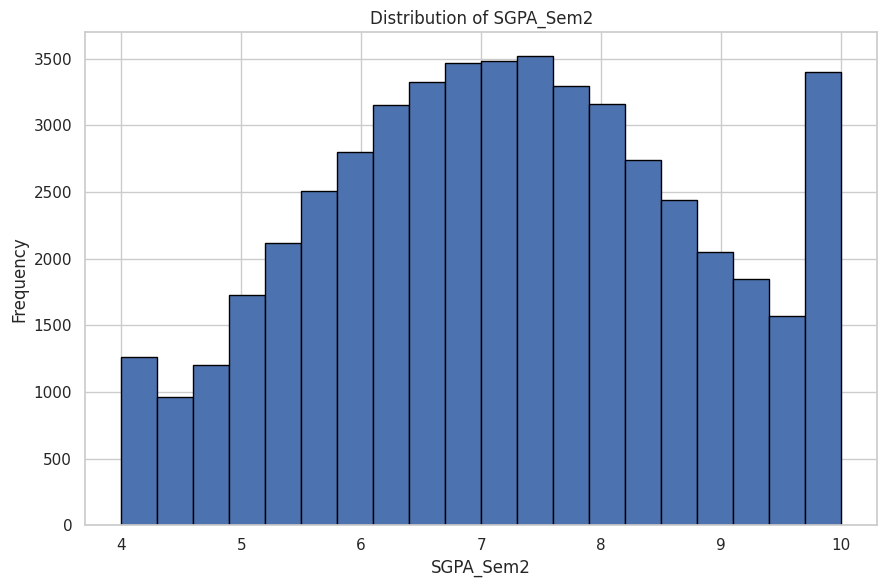

Saved: 43_histogram_SGPA_Sem2.png


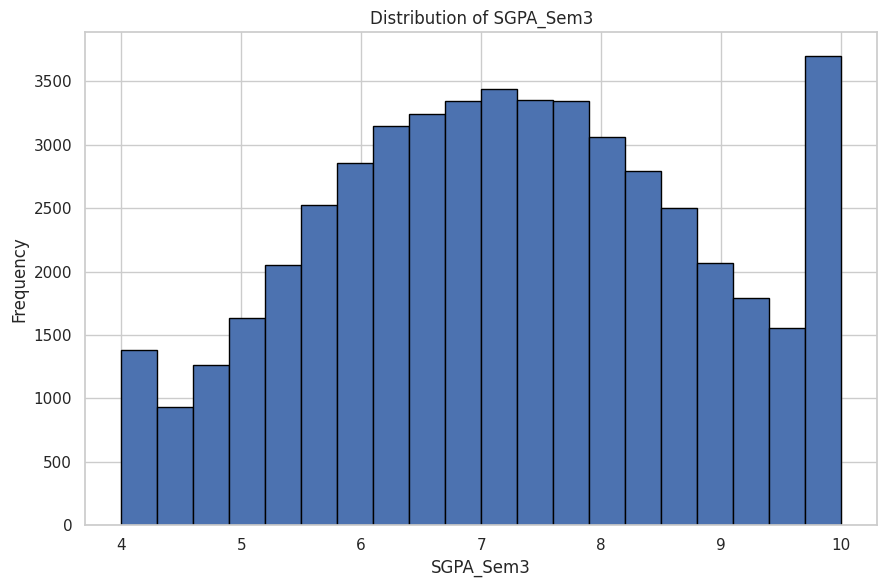

Saved: 44_histogram_SGPA_Sem3.png


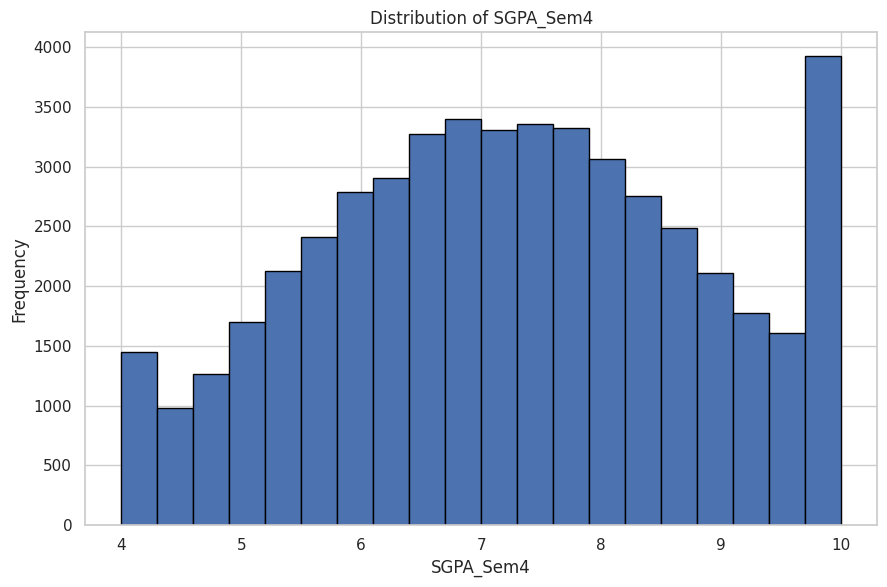

Saved: 45_histogram_SGPA_Sem4.png


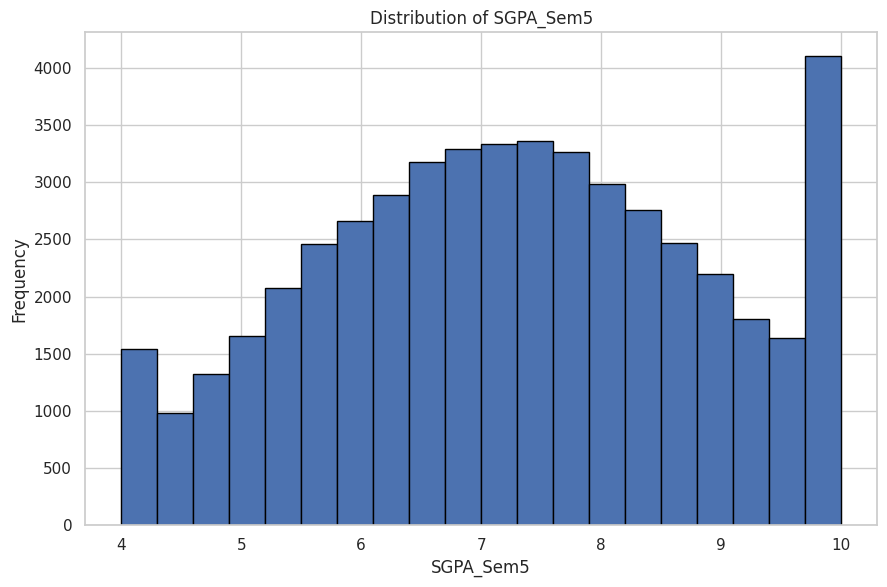

Saved: 46_histogram_SGPA_Sem5.png


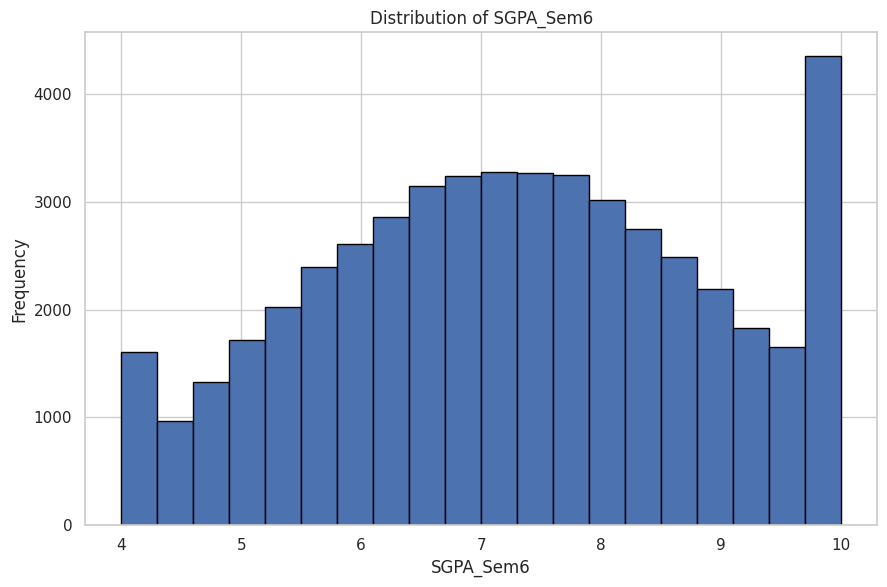

Saved: 47_histogram_SGPA_Sem6.png


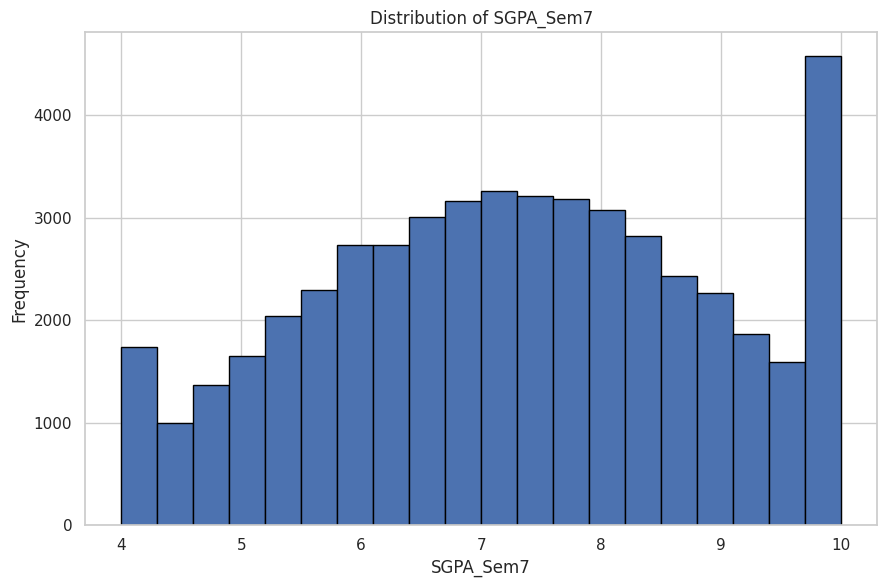

Saved: 48_histogram_SGPA_Sem7.png


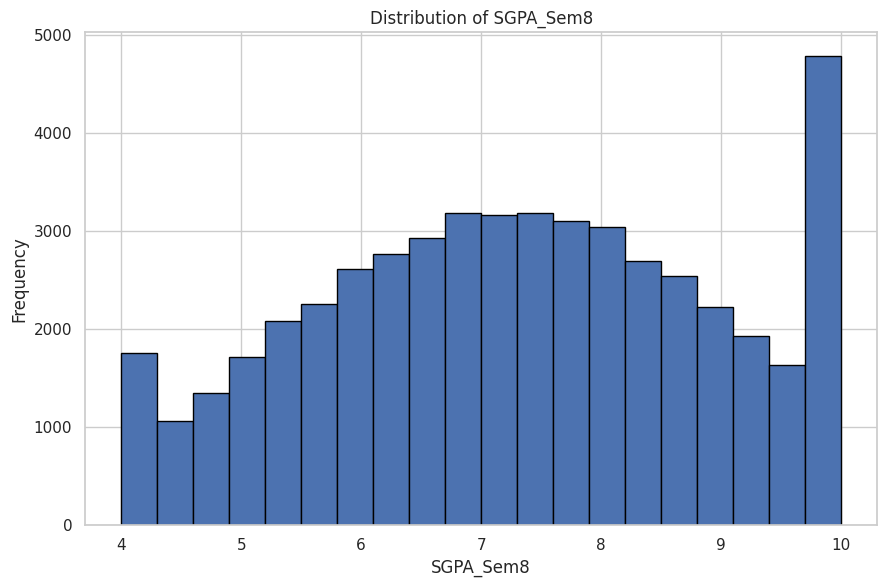

Saved: 49_histogram_SGPA_Sem8.png


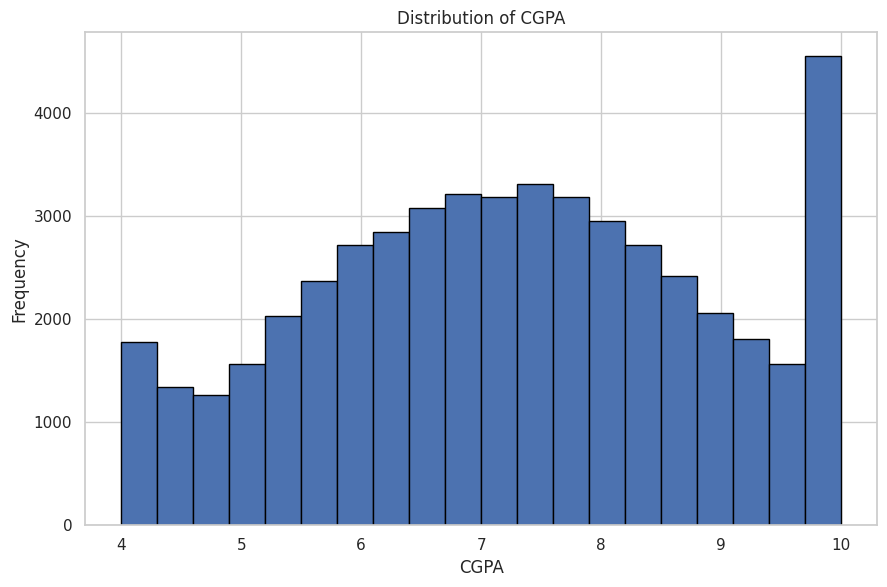

Saved: 50_histogram_CGPA.png


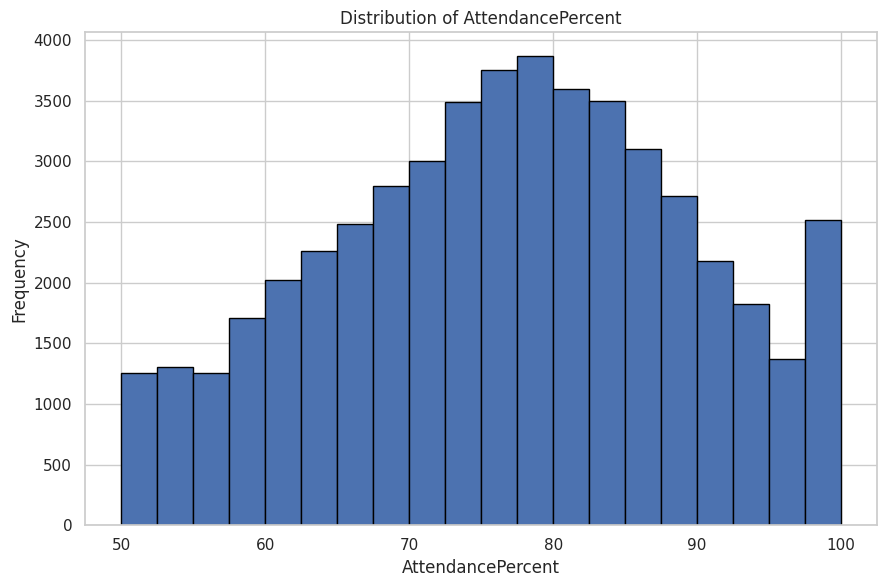

Saved: 51_histogram_AttendancePercent.png


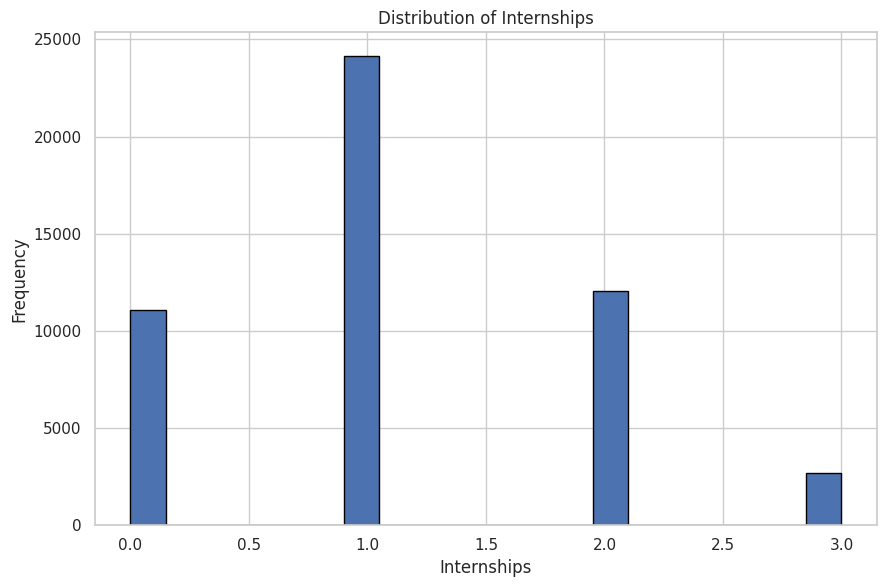

Saved: 52_histogram_Internships.png


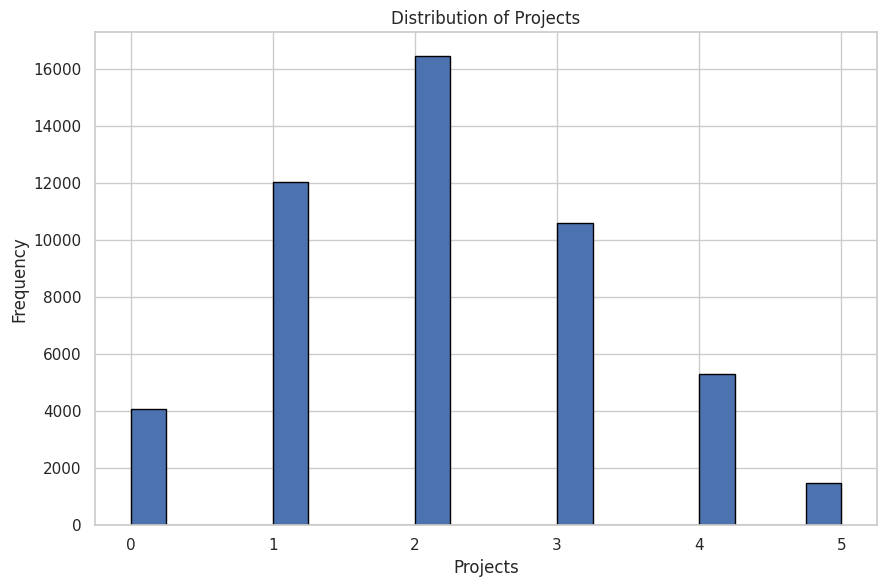

Saved: 53_histogram_Projects.png


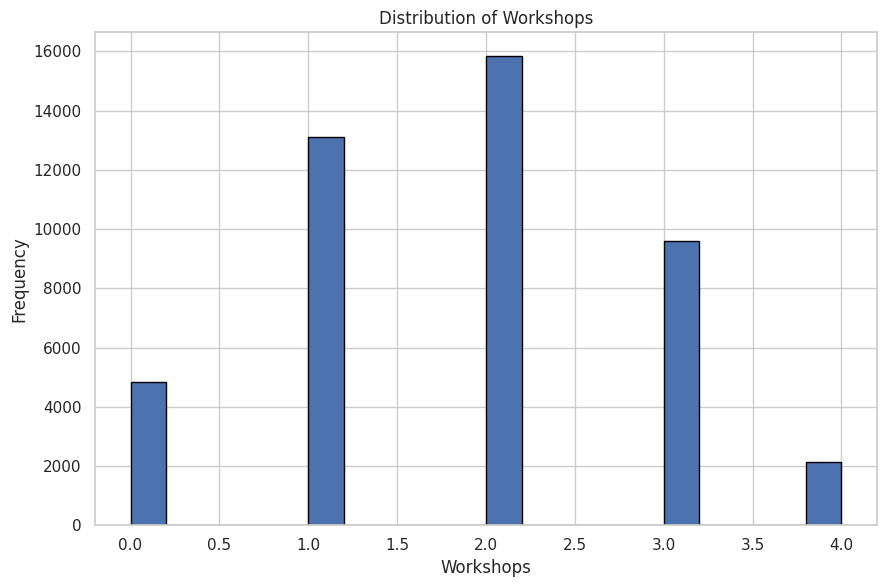

Saved: 54_histogram_Workshops.png


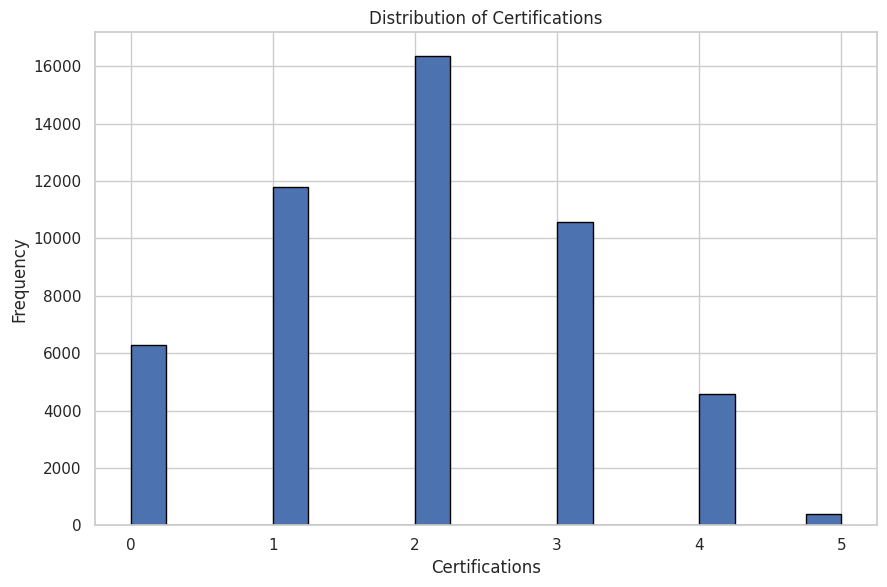

Saved: 55_histogram_Certifications.png


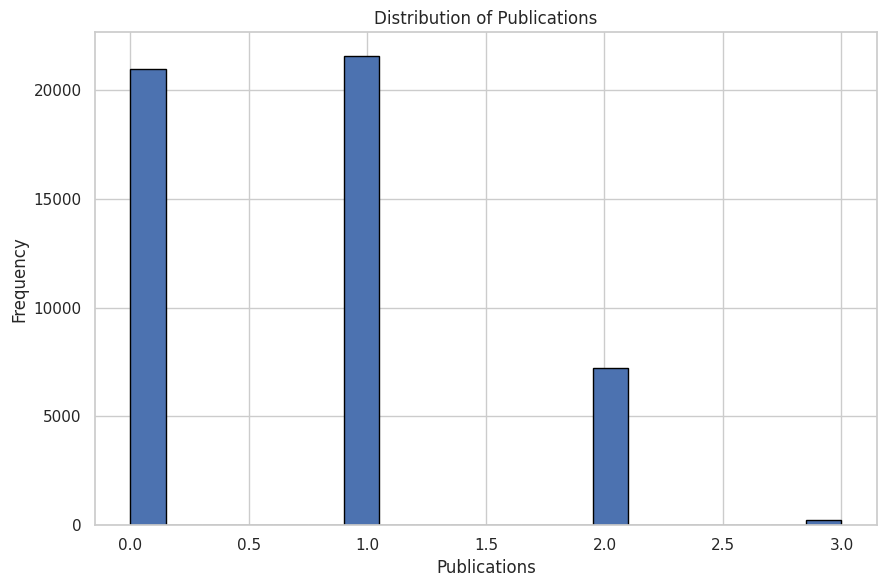

Saved: 56_histogram_Publications.png


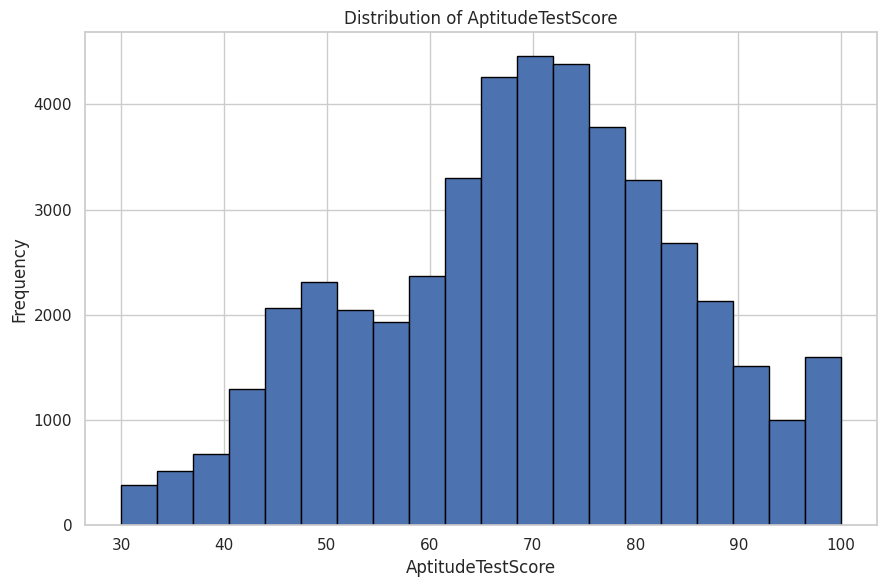

Saved: 57_histogram_AptitudeTestScore.png


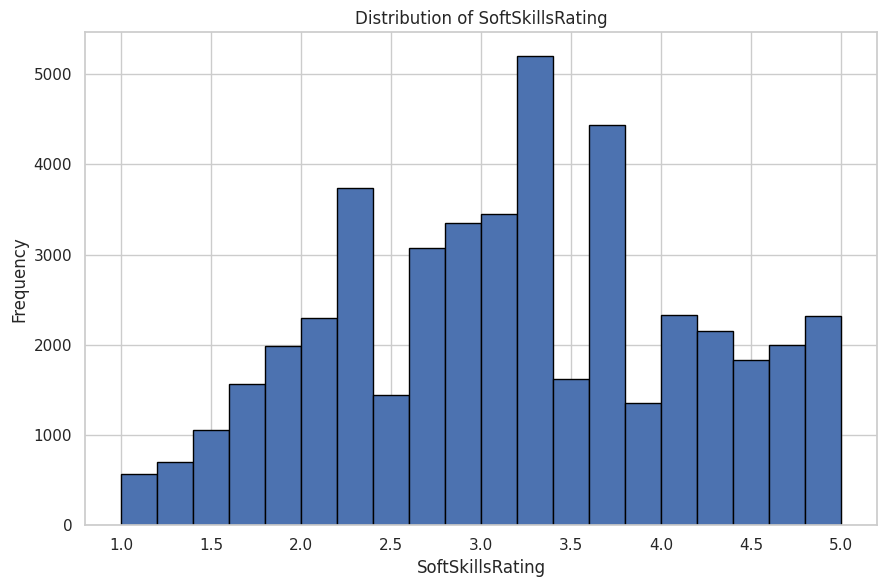

Saved: 58_histogram_SoftSkillsRating.png


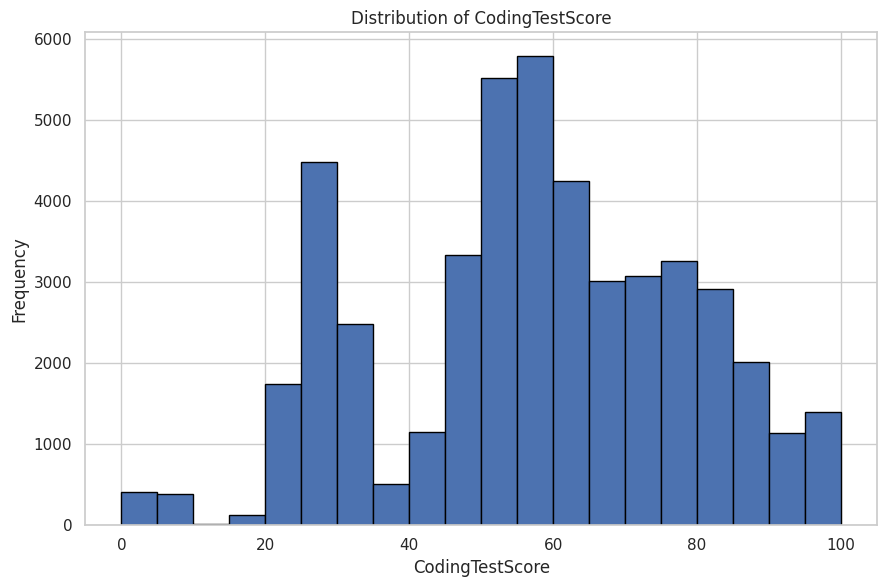

Saved: 59_histogram_CodingTestScore.png


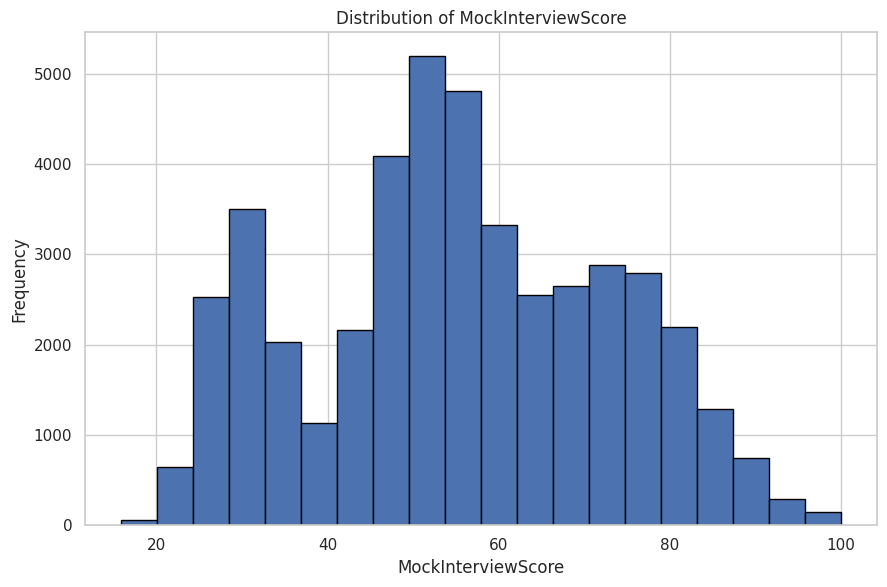

Saved: 60_histogram_MockInterviewScore.png


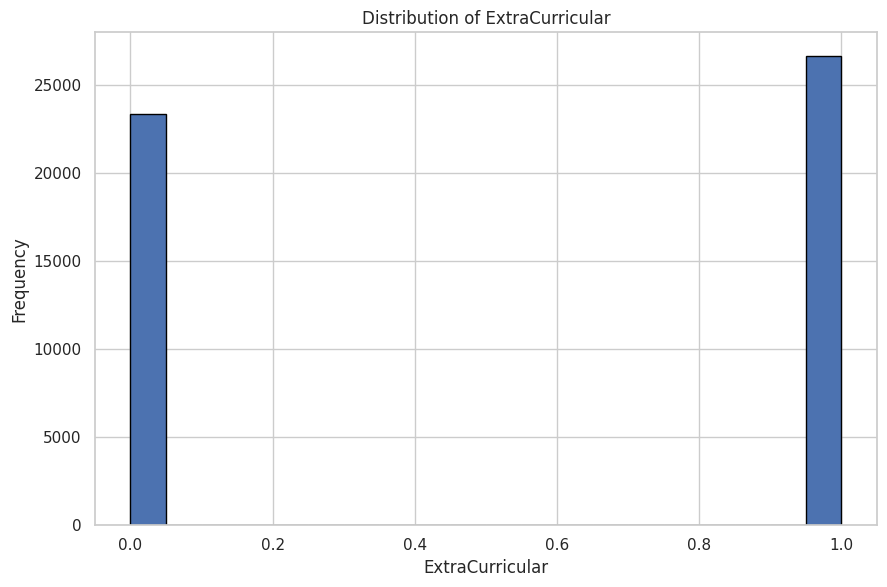

Saved: 61_histogram_ExtraCurricular.png


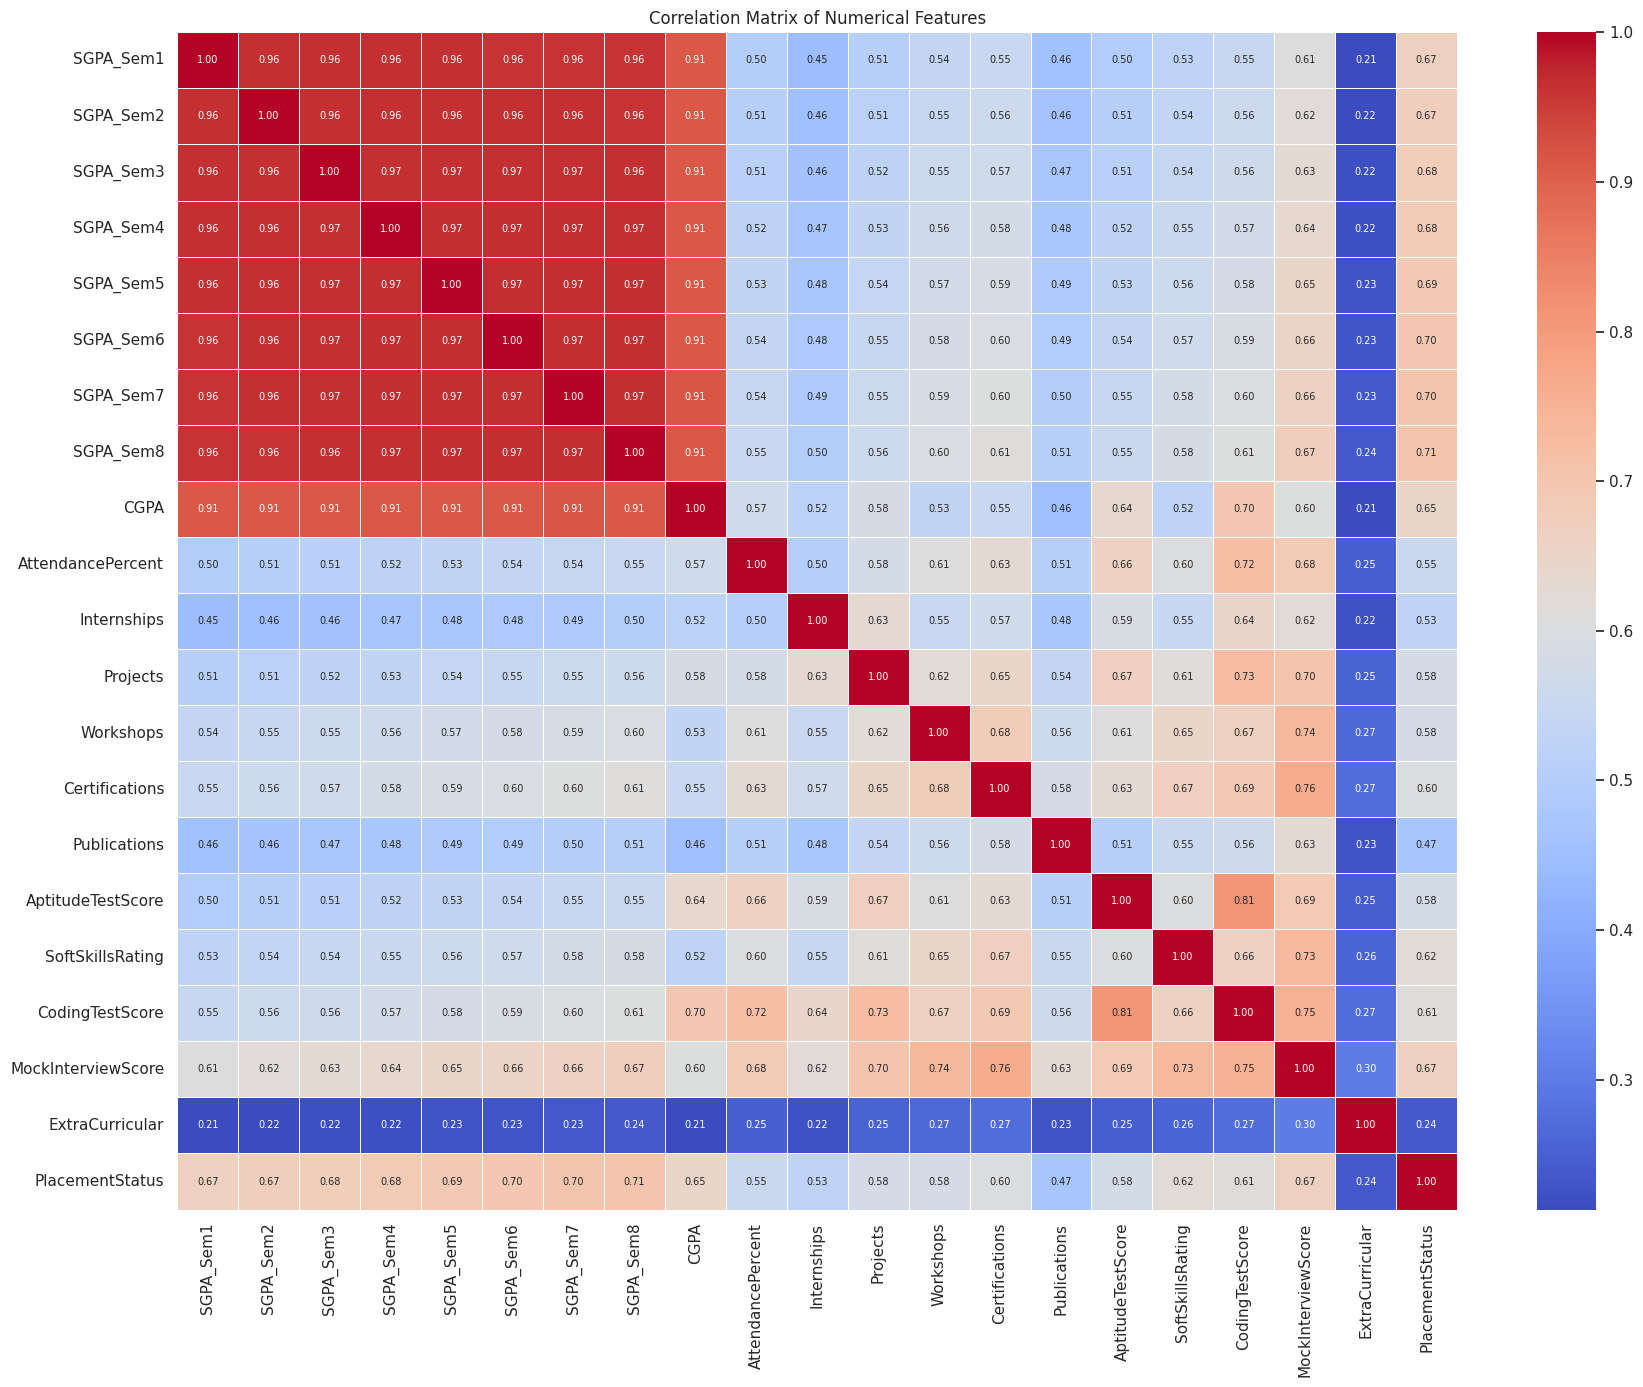

Saved: 70_correlation_matrix.png


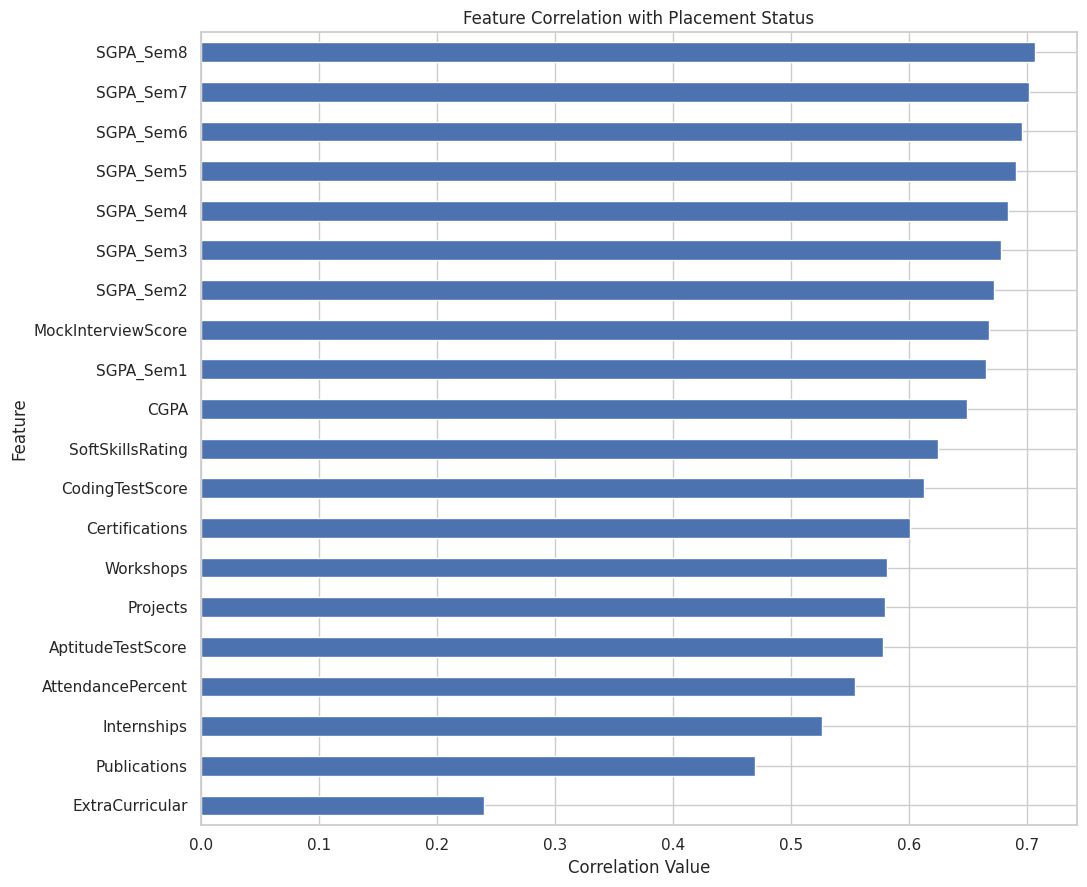

Saved: 71_placement_feature_correlation.png
Dataset summary saved
Missing-value report saved
Correlation table saved

ALL GRAPHS CREATED SUCCESSFULLY
Graph folder: /content/placement_all_graphs
ZIP file: /content/placement_all_graphs.zip
Total files generated: 67


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [123]:
# ============================================================
# PLACEMENT DATASET — CREATE AND DOWNLOAD ALL GRAPHS AS ZIP
# ============================================================

import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt

# Optional: install seaborn if it is not available
try:
    import seaborn as sns
except ImportError:
    !pip install seaborn -q
    import seaborn as sns


# ============================================================
# 1. READ THE CSV FILE
# ============================================================

file_path = "/content/placement_predict_50k Dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())


# ============================================================
# 2. CREATE FOLDER FOR ALL GRAPHS
# ============================================================

graph_folder = "/content/placement_all_graphs"

# Remove the old folder if it already exists
if os.path.exists(graph_folder):
    shutil.rmtree(graph_folder)

os.makedirs(graph_folder)

print("Graph folder created:", graph_folder)


# ============================================================
# 3. GENERAL GRAPH SETTINGS
# ============================================================

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11


# ============================================================
# HELPER FUNCTION TO SAVE EACH GRAPH
# ============================================================

def save_graph(file_name):
    """
    Saves the current graph inside the graph folder.
    """

    full_path = os.path.join(graph_folder, file_name)

    plt.tight_layout()

    plt.savefig(
        full_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print("Saved:", file_name)


# ============================================================
# 4. PLACEMENT STATUS BAR GRAPH
# ============================================================

placement_counts = (
    df["PlacementStatus"]
    .value_counts()
    .sort_index()
)

placement_labels = {
    0: "Not Placed",
    1: "Placed"
}

placement_counts.index = [
    placement_labels.get(value, str(value))
    for value in placement_counts.index
]

plt.figure(figsize=(8, 6))

placement_counts.plot(kind="bar")

plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

for index, value in enumerate(placement_counts):
    plt.text(
        index,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

save_graph("01_placement_status_bar.png")


# ============================================================
# 5. PLACEMENT STATUS PIE CHART
# ============================================================

plt.figure(figsize=(8, 8))

plt.pie(
    placement_counts.values,
    labels=placement_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Placement Status Percentage")

save_graph("02_placement_status_pie.png")


# ============================================================
# 6. GENDER DISTRIBUTION
# ============================================================

gender_counts = df["Gender"].value_counts(dropna=False)

plt.figure(figsize=(8, 6))

gender_counts.plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

save_graph("03_gender_distribution.png")


# ============================================================
# 7. PLACEMENT STATUS BY GENDER
# ============================================================

gender_placement = pd.crosstab(
    df["Gender"],
    df["PlacementStatus"]
)

gender_placement = gender_placement.rename(
    columns={
        0: "Not Placed",
        1: "Placed"
    }
)

gender_placement.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Placement Status by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.legend(title="Placement Status")

save_graph("04_placement_by_gender.png")


# ============================================================
# 8. STREAM DISTRIBUTION
# ============================================================

stream_counts = df["Stream"].value_counts()

plt.figure(figsize=(12, 7))

stream_counts.plot(kind="bar")

plt.title("Student Distribution by Stream")
plt.xlabel("Stream")
plt.ylabel("Number of Students")
plt.xticks(rotation=45, ha="right")

save_graph("05_stream_distribution.png")


# ============================================================
# 9. PLACEMENT STATUS BY STREAM
# ============================================================

stream_placement = pd.crosstab(
    df["Stream"],
    df["PlacementStatus"]
)

stream_placement = stream_placement.rename(
    columns={
        0: "Not Placed",
        1: "Placed"
    }
)

stream_placement.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Placement Status by Stream")
plt.xlabel("Stream")
plt.ylabel("Number of Students")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Placement Status")

save_graph("06_placement_by_stream.png")


# ============================================================
# 10. CITY DISTRIBUTION — TOP 15 CITIES
# ============================================================

top_cities = df["City"].value_counts().head(15)

plt.figure(figsize=(12, 7))

top_cities.sort_values().plot(kind="barh")

plt.title("Top 15 Cities by Number of Students")
plt.xlabel("Number of Students")
plt.ylabel("City")

save_graph("07_top_15_cities.png")


# ============================================================
# 11. COLLEGE TIER DISTRIBUTION
# ============================================================

college_tier_counts = df["CollegeTier"].value_counts()

plt.figure(figsize=(8, 6))

college_tier_counts.plot(kind="bar")

plt.title("College Tier Distribution")
plt.xlabel("College Tier")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

save_graph("08_college_tier_distribution.png")


# ============================================================
# 12. PLACEMENT STATUS BY COLLEGE TIER
# ============================================================

college_placement = pd.crosstab(
    df["CollegeTier"],
    df["PlacementStatus"]
)

college_placement = college_placement.rename(
    columns={
        0: "Not Placed",
        1: "Placed"
    }
)

college_placement.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Placement Status by College Tier")
plt.xlabel("College Tier")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.legend(title="Placement Status")

save_graph("09_placement_by_college_tier.png")


# ============================================================
# 13. SPECIALISATION DISTRIBUTION — TOP 15
# ============================================================

specialisation_counts = (
    df["Specialisation"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12, 8))

specialisation_counts.sort_values().plot(kind="barh")

plt.title("Top 15 Specialisations")
plt.xlabel("Number of Students")
plt.ylabel("Specialisation")

save_graph("10_top_15_specialisations.png")


# ============================================================
# 14. CGPA HISTOGRAM
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["CGPA"].dropna(),
    bins=25,
    edgecolor="black"
)

plt.title("CGPA Distribution")
plt.xlabel("CGPA")
plt.ylabel("Number of Students")

save_graph("11_cgpa_histogram.png")


# ============================================================
# 15. CGPA BOX PLOT
# ============================================================

plt.figure(figsize=(8, 6))

plt.boxplot(
    df["CGPA"].dropna(),
    vert=True
)

plt.title("Box Plot of CGPA")
plt.ylabel("CGPA")

save_graph("12_cgpa_boxplot.png")


# ============================================================
# 16. CGPA BY PLACEMENT STATUS
# ============================================================

not_placed_cgpa = (
    df[df["PlacementStatus"] == 0]["CGPA"]
    .dropna()
)

placed_cgpa = (
    df[df["PlacementStatus"] == 1]["CGPA"]
    .dropna()
)

plt.figure(figsize=(9, 6))

plt.boxplot(
    [not_placed_cgpa, placed_cgpa],
    tick_labels=["Not Placed", "Placed"]
)

plt.title("CGPA by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("CGPA")

save_graph("13_cgpa_by_placement.png")


# ============================================================
# 17. ATTENDANCE HISTOGRAM
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["AttendancePercent"].dropna(),
    bins=25,
    edgecolor="black"
)

plt.title("Attendance Percentage Distribution")
plt.xlabel("Attendance Percentage")
plt.ylabel("Number of Students")

save_graph("14_attendance_histogram.png")


# ============================================================
# 18. ATTENDANCE BY PLACEMENT STATUS
# ============================================================

not_placed_attendance = (
    df[df["PlacementStatus"] == 0]["AttendancePercent"]
    .dropna()
)

placed_attendance = (
    df[df["PlacementStatus"] == 1]["AttendancePercent"]
    .dropna()
)

plt.figure(figsize=(9, 6))

plt.boxplot(
    [not_placed_attendance, placed_attendance],
    tick_labels=["Not Placed", "Placed"]
)

plt.title("Attendance by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Attendance Percentage")

save_graph("15_attendance_by_placement.png")


# ============================================================
# 19. APTITUDE TEST SCORE HISTOGRAM
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["AptitudeTestScore"].dropna(),
    bins=25,
    edgecolor="black"
)

plt.title("Aptitude Test Score Distribution")
plt.xlabel("Aptitude Test Score")
plt.ylabel("Number of Students")

save_graph("16_aptitude_score_histogram.png")


# ============================================================
# 20. CODING TEST SCORE HISTOGRAM
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["CodingTestScore"].dropna(),
    bins=25,
    edgecolor="black"
)

plt.title("Coding Test Score Distribution")
plt.xlabel("Coding Test Score")
plt.ylabel("Number of Students")

save_graph("17_coding_score_histogram.png")


# ============================================================
# 21. MOCK INTERVIEW SCORE HISTOGRAM
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["MockInterviewScore"].dropna(),
    bins=25,
    edgecolor="black"
)

plt.title("Mock Interview Score Distribution")
plt.xlabel("Mock Interview Score")
plt.ylabel("Number of Students")

save_graph("18_mock_interview_histogram.png")


# ============================================================
# 22. SOFT SKILLS RATING HISTOGRAM
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["SoftSkillsRating"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title("Soft Skills Rating Distribution")
plt.xlabel("Soft Skills Rating")
plt.ylabel("Number of Students")

save_graph("19_soft_skills_histogram.png")


# ============================================================
# 23. CGPA VS CODING TEST SCORE
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    df["CGPA"],
    df["CodingTestScore"],
    alpha=0.3
)

plt.title("CGPA vs Coding Test Score")
plt.xlabel("CGPA")
plt.ylabel("Coding Test Score")

save_graph("20_cgpa_vs_coding_score.png")


# ============================================================
# 24. APTITUDE SCORE VS CODING SCORE
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    df["AptitudeTestScore"],
    df["CodingTestScore"],
    alpha=0.3
)

plt.title("Aptitude Score vs Coding Score")
plt.xlabel("Aptitude Test Score")
plt.ylabel("Coding Test Score")

save_graph("21_aptitude_vs_coding_score.png")


# ============================================================
# 25. CGPA VS ATTENDANCE
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    df["CGPA"],
    df["AttendancePercent"],
    alpha=0.3
)

plt.title("CGPA vs Attendance Percentage")
plt.xlabel("CGPA")
plt.ylabel("Attendance Percentage")

save_graph("22_cgpa_vs_attendance.png")


# ============================================================
# 26. CODING SCORE VS MOCK INTERVIEW SCORE
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    df["CodingTestScore"],
    df["MockInterviewScore"],
    alpha=0.3
)

plt.title("Coding Test Score vs Mock Interview Score")
plt.xlabel("Coding Test Score")
plt.ylabel("Mock Interview Score")

save_graph("23_coding_vs_mock_interview.png")


# ============================================================
# 27. INTERNSHIP DISTRIBUTION
# ============================================================

internship_counts = (
    df["Internships"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 6))

internship_counts.plot(kind="bar")

plt.title("Internship Distribution")
plt.xlabel("Number of Internships")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

save_graph("24_internship_distribution.png")


# ============================================================
# 28. PLACEMENT STATUS BY INTERNSHIPS
# ============================================================

internship_placement = pd.crosstab(
    df["Internships"],
    df["PlacementStatus"]
)

internship_placement = internship_placement.rename(
    columns={
        0: "Not Placed",
        1: "Placed"
    }
)

internship_placement.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Placement Status by Number of Internships")
plt.xlabel("Number of Internships")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.legend(title="Placement Status")

save_graph("25_placement_by_internships.png")


# ============================================================
# 29. PROJECT DISTRIBUTION
# ============================================================

project_counts = (
    df["Projects"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 6))

project_counts.plot(kind="bar")

plt.title("Project Distribution")
plt.xlabel("Number of Projects")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

save_graph("26_project_distribution.png")


# ============================================================
# 30. PLACEMENT STATUS BY PROJECTS
# ============================================================

project_placement = pd.crosstab(
    df["Projects"],
    df["PlacementStatus"]
)

project_placement = project_placement.rename(
    columns={
        0: "Not Placed",
        1: "Placed"
    }
)

project_placement.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Placement Status by Number of Projects")
plt.xlabel("Number of Projects")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.legend(title="Placement Status")

save_graph("27_placement_by_projects.png")


# ============================================================
# 31. CERTIFICATION DISTRIBUTION
# ============================================================

certification_counts = (
    df["Certifications"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 6))

certification_counts.plot(kind="bar")

plt.title("Certification Distribution")
plt.xlabel("Number of Certifications")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

save_graph("28_certification_distribution.png")


# ============================================================
# 32. BACKLOG HISTORY DISTRIBUTION
# ============================================================

backlog_counts = (
    df["HistoryOfBacklogs"]
    .value_counts(dropna=False)
)

plt.figure(figsize=(8, 6))

backlog_counts.plot(kind="bar")

plt.title("History of Backlogs Distribution")
plt.xlabel("History of Backlogs")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

save_graph("29_backlog_distribution.png")


# ============================================================
# 33. PLACEMENT STATUS BY BACKLOG HISTORY
# ============================================================

backlog_placement = pd.crosstab(
    df["HistoryOfBacklogs"],
    df["PlacementStatus"]
)

backlog_placement = backlog_placement.rename(
    columns={
        0: "Not Placed",
        1: "Placed"
    }
)

backlog_placement.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Placement Status by Backlog History")
plt.xlabel("History of Backlogs")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.legend(title="Placement Status")

save_graph("30_placement_by_backlogs.png")


# ============================================================
# 34. HOSTEL DISTRIBUTION
# ============================================================

hostel_counts = df["Hostel"].value_counts(dropna=False)

plt.figure(figsize=(8, 6))

hostel_counts.plot(kind="bar")

plt.title("Hostel Distribution")
plt.xlabel("Hostel")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

save_graph("31_hostel_distribution.png")


# ============================================================
# 35. CGPA TIER DISTRIBUTION
# ============================================================

cgpa_tier_counts = df["CGPA_Tier"].value_counts(dropna=False)

plt.figure(figsize=(10, 6))

cgpa_tier_counts.plot(kind="bar")

plt.title("CGPA Tier Distribution")
plt.xlabel("CGPA Tier")
plt.ylabel("Number of Students")
plt.xticks(rotation=30, ha="right")

save_graph("32_cgpa_tier_distribution.png")


# ============================================================
# 36. PLACEMENT STATUS BY CGPA TIER
# ============================================================

cgpa_tier_placement = pd.crosstab(
    df["CGPA_Tier"],
    df["PlacementStatus"]
)

cgpa_tier_placement = cgpa_tier_placement.rename(
    columns={
        0: "Not Placed",
        1: "Placed"
    }
)

cgpa_tier_placement.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Placement Status by CGPA Tier")
plt.xlabel("CGPA Tier")
plt.ylabel("Number of Students")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Placement Status")

save_graph("33_placement_by_cgpa_tier.png")


# ============================================================
# 37. SEMESTER SGPA TREND
# ============================================================

semester_columns = [
    "SGPA_Sem1",
    "SGPA_Sem2",
    "SGPA_Sem3",
    "SGPA_Sem4",
    "SGPA_Sem5",
    "SGPA_Sem6",
    "SGPA_Sem7",
    "SGPA_Sem8"
]

semester_average = df[semester_columns].mean()

semester_average.index = [
    "Semester 1",
    "Semester 2",
    "Semester 3",
    "Semester 4",
    "Semester 5",
    "Semester 6",
    "Semester 7",
    "Semester 8"
]

plt.figure(figsize=(11, 6))

plt.plot(
    semester_average.index,
    semester_average.values,
    marker="o"
)

plt.title("Average SGPA Across Semesters")
plt.xlabel("Semester")
plt.ylabel("Average SGPA")
plt.xticks(rotation=30)

save_graph("34_average_semester_sgpa.png")


# ============================================================
# 38. AVERAGE SCORES BY PLACEMENT STATUS
# ============================================================

score_columns = [
    "AttendancePercent",
    "AptitudeTestScore",
    "CodingTestScore",
    "MockInterviewScore"
]

average_scores = (
    df.groupby("PlacementStatus")[score_columns]
    .mean()
)

average_scores.index = [
    "Not Placed",
    "Placed"
]

average_scores.T.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Average Scores by Placement Status")
plt.xlabel("Student Performance Feature")
plt.ylabel("Average Score")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Placement Status")

save_graph("35_average_scores_by_placement.png")


# ============================================================
# 39. NUMERICAL FEATURE BOX PLOTS
# ============================================================

boxplot_columns = [
    "CGPA",
    "AttendancePercent",
    "AptitudeTestScore",
    "CodingTestScore",
    "MockInterviewScore",
    "SoftSkillsRating"
]

for number, column in enumerate(boxplot_columns, start=36):

    plt.figure(figsize=(8, 6))

    plt.boxplot(
        df[column].dropna()
    )

    plt.title(f"Box Plot of {column}")
    plt.ylabel(column)

    save_graph(
        f"{number:02d}_boxplot_{column}.png"
    )


# ============================================================
# 40. HISTOGRAMS FOR ALL NUMERICAL COLUMNS
# ============================================================

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Remove identifier and target-related columns from general histograms
excluded_columns = [
    "StudentID",
    "PlacementStatus",
    "IsAnomaly"
]

histogram_columns = [
    column
    for column in numerical_columns
    if column not in excluded_columns
]

for number, column in enumerate(histogram_columns, start=42):

    plt.figure(figsize=(9, 6))

    plt.hist(
        df[column].dropna(),
        bins=20,
        edgecolor="black"
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    save_graph(
        f"{number:02d}_histogram_{column}.png"
    )


# ============================================================
# 41. CORRELATION MATRIX
# ============================================================

correlation_columns = [
    "SGPA_Sem1",
    "SGPA_Sem2",
    "SGPA_Sem3",
    "SGPA_Sem4",
    "SGPA_Sem5",
    "SGPA_Sem6",
    "SGPA_Sem7",
    "SGPA_Sem8",
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore",
    "ExtraCurricular",
    "PlacementStatus"
]

correlation = df[correlation_columns].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size": 7}
)

plt.title("Correlation Matrix of Numerical Features")

save_graph("70_correlation_matrix.png")


# ============================================================
# 42. PLACEMENT CORRELATION GRAPH
# ============================================================

placement_correlation = (
    correlation["PlacementStatus"]
    .drop("PlacementStatus")
    .sort_values()
)

plt.figure(figsize=(11, 9))

placement_correlation.plot(kind="barh")

plt.title("Feature Correlation with Placement Status")
plt.xlabel("Correlation Value")
plt.ylabel("Feature")

save_graph("71_placement_feature_correlation.png")


# ============================================================
# 43. SAVE DATASET SUMMARY
# ============================================================

summary_file = os.path.join(
    graph_folder,
    "dataset_summary.txt"
)

with open(summary_file, "w", encoding="utf-8") as file:

    file.write("PLACEMENT DATASET SUMMARY\n")
    file.write("=" * 60 + "\n\n")

    file.write(f"Number of rows: {df.shape[0]}\n")
    file.write(f"Number of columns: {df.shape[1]}\n")

    file.write(
        f"Total missing values: {df.isnull().sum().sum()}\n"
    )

    file.write(
        f"Duplicate rows: {df.duplicated().sum()}\n\n"
    )

    file.write("COLUMN NAMES\n")
    file.write("-" * 60 + "\n")

    for column in df.columns:
        file.write(f"{column}\n")

    file.write("\n\nMISSING VALUES\n")
    file.write("-" * 60 + "\n")
    file.write(df.isnull().sum().to_string())

    file.write("\n\nPLACEMENT STATUS COUNTS\n")
    file.write("-" * 60 + "\n")
    file.write(
        df["PlacementStatus"]
        .value_counts()
        .sort_index()
        .to_string()
    )

    file.write("\n\nNUMERICAL SUMMARY\n")
    file.write("-" * 60 + "\n")
    file.write(df.describe().to_string())

print("Dataset summary saved")


# ============================================================
# 44. SAVE MISSING-VALUE REPORT
# ============================================================

missing_report = pd.DataFrame({
    "Column": df.columns,
    "MissingValues": df.isnull().sum().values,
    "MissingPercentage":
        (df.isnull().sum().values / len(df)) * 100
})

missing_report.to_csv(
    os.path.join(
        graph_folder,
        "missing_value_report.csv"
    ),
    index=False
)

print("Missing-value report saved")


# ============================================================
# 45. SAVE CORRELATION TABLE
# ============================================================

correlation.to_csv(
    os.path.join(
        graph_folder,
        "correlation_matrix.csv"
    )
)

print("Correlation table saved")


# ============================================================
# 46. CREATE LIST OF GENERATED GRAPH FILES
# ============================================================

generated_files = sorted(
    os.listdir(graph_folder)
)

graph_list_file = os.path.join(
    graph_folder,
    "generated_files_list.txt"
)

with open(graph_list_file, "w", encoding="utf-8") as file:

    file.write("GENERATED FILES\n")
    file.write("=" * 50 + "\n")

    for number, file_name in enumerate(
        generated_files,
        start=1
    ):
        file.write(f"{number}. {file_name}\n")


# ============================================================
# 47. CREATE ZIP FILE
# ============================================================

zip_base_path = "/content/placement_all_graphs"

zip_file = shutil.make_archive(
    zip_base_path,
    "zip",
    graph_folder
)

print("\n" + "=" * 70)
print("ALL GRAPHS CREATED SUCCESSFULLY")
print("=" * 70)

print("Graph folder:", graph_folder)
print("ZIP file:", zip_file)
print("Total files generated:", len(os.listdir(graph_folder)))


# ============================================================
# 48. DOWNLOAD ZIP FILE
# ============================================================

from google.colab import files

files.download(zip_file)